In [1]:
# Loading some required liberaries
from __future__ import division
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation
from scipy import interpolate 
import scipy as scipy
#from cmcrameri import cm 
import math
import V2RhoT_gibbs_lib as lib


# Pressure

In [2]:
########################################
# Defining pressure function based on Ak133
# I choose ak135 becaouse the pressures from the LitMod2D_2.0 ref model
# are practically similar to ak135
########################################
try:
    ak135 = np.loadtxt('./databases/ak135f.txt',skiprows=1)
except:
    ak135 = np.loadtxt('/home/ajay/projects/V2RhoT_gibbs/databases/ak135f.txt',skiprows=1)

ak135_P = 9.8*ak135[:,0]*1e3*ak135[:,1]*1e3*1e-5
#pressure_inter = interpolate.interp1d(ak135[:,0],ak135_P)
#depth_inter = interpolate.interp1d(ak135_P,ak135[:,0])
y2=ak135[:,1]*9.8
gravity=9.8
density=ak135[:,1]*1e3
depth=ak135[:,0]*1e3
pressure_int = scipy.integrate.cumulative_trapezoid(gravity * density, x=depth, initial=0)
pressure_int=pressure_int*1e-5 # pascal to bar
pressure_inter = interpolate.interp1d(ak135[:,0],pressure_int)

# Melt and atten functions

In [3]:
## melt fraction - mantle
def melt_frac_mantle_Hirschmann(T,P):
    """
    Hirschmann, 2000 and Winter, 2010
    P in GPa
    T in oC
    """
    T_s_m = 1080.0 + 134.2*P - 6.581*P**2 + 0.1054*P**3
    T_l_m = 1762.0 + 57.46*P  - 3.487*P**2 + 0.077*P**3
    melt  = (T - T_s_m)/(T_l_m - T_s_m)
    return melt
def melt_frac_mantle_Hirschmann(T, P):
    """
    Hirschmann, 2000 and Winter, 2010
    P in GPa, T in °C
    Supports both scalar values and NumPy arrays.
    """
    T_s_m = 1080.0 + 134.2*P - 6.581*P**2 + 0.1054*P**3
    T_l_m = 1762.0 + 57.46*P  - 3.487*P**2 + 0.077*P**3
    
    # Avoid potential division by zero if T_l_m equals T_s_m
    denominator = np.where(T_l_m == T_s_m, 1e-5, T_l_m - T_s_m)
    melt = (T - T_s_m) / denominator
    # Restrict bounds cleanly to [0.0, 1.0]
    return np.clip(melt, 0.0, 1.0)
def velocity_melt_correction_mantle_Hammond_Humphreys_new(T, P, Vp, Vs):
    """
    Hammond_Humphreys¸
    """
    ## get the melt fraction at the P and T
    melt_frac = melt_frac_mantle_Hirschmann(T,P)
    #########################
    # Vs:   -5.3 = dlnVs/melt_frac => dlnVs = -5.3 * melt_frac
    # Vp:   -2.4 = dlnVp/melt_frac => dlnVp = -2.4 * melt_frac
    if melt_frac > 0:
        dVs = -5.3 * melt_frac
        dVp = -2.4 * melt_frac
        Vs_corrected = Vs*np.exp(dVs)
        Vp_corrected = Vp*np.exp(dVp)
    else:
        Vp_corrected = Vp
        Vs_corrected = Vs
        melt_frac    = 0.
    return Vp_corrected,Vs_corrected, melt_frac*100.
def velocity_melt_correction_mantle_Hammond_Humphreys_orig(T,P,Vp,Vs):
    """
    Hammond_Humphreys¸
    """
    ## get the melt fraction at the P and T
    melt_frac = melt_frac_mantle_Hirschmann(T,P)
    #########################
    # Vs:   -5.3 = dlnVs/%melt => dlnVs = -5.3 * %melt
    # Vp:   -2.4 = dlnVp/%melt => dlnVp = -2.4 * %melt
    '''
    dVs = np.exp(-5.3 * melt_frac)
    dVp = np.exp(-2.3 * melt_frac)
    Vp_corrected = Vp - dVp
    Vs_corrected = Vs - dVs
    '''
    if melt_frac > 0:
        dVs = -5.3 * melt_frac*100
        dVp = -2.4 * melt_frac*100
        Vs_corrected = Vs*np.exp(dVs)
        Vp_corrected = Vp*np.exp(dVp)
    else:
        Vp_corrected = Vp
        Vs_corrected = Vs
        melt_frac    = 0.
    return Vp_corrected,Vs_corrected, melt_frac*100.
def atten_correction_JF2010_orig(T,P,Vp,Vs,oscill,grain_size,alfa=0.36,energy=293e3):
    '''
    Jackson and Faul, 2010 and Kumar et al., 2020    
    Input:
    T - Kelvin
    P - Pascal
    Vp,Vs - km/s 
    oscill - time period (seconds)
    d - mm
    Output:
    Vp,Vs: km/s    
    '''
    ## Parameters from Jackson and Faule 2010, Kumar et al., 2020
    A = 816.0          # (𝑠^(−𝛼) 〖𝜇𝑚〗^(−𝛼))Pre-exponential factor (for d in micrometers)
    #A = 68          # 𝑠^(−𝛼) 〖𝑚𝑚〗^(−𝛼)Pre-exponential factor (for d in mm)
    #alfa   = 0.34      #------------ frequency dependence
    energy = 293e3  #------------ Activation energy
    volexp = 1.20e-5  #------------ Activation volume
    R      = 8.314472  #------------ Gas constant
    pi     = 3.1415926 #------------ shephard;s pie :)

    #################################################
    ## calculating Qp and Qs
    parexp    = math.exp((-(energy+(volexp*P)))/(R*(T)))
    sqatt50   = A*(((oscill*(1.0/(grain_size*1e3)))*parexp))**alfa
    Qp        = (1/sqatt50)*(9/4)
    Qs        = 1/sqatt50
    cots50    = ((1.0/math.tan((pi*alfa)/2.0))*sqatt50)*0.5
    cotp50    = ((1.0/math.tan((pi*alfa)/2.0))*sqatt50)*(2.0/9.0)
    #################################################
    ## correcting velocities
    Vs_correc = Vs*(1.0-cots50)
    Vp_correc = Vp*(1.0-cotp50)
    return Vp_correc,Vs_correc

def atten_correction_JF2010_new(T,P,Vp,Vs,oscill,grain_size,A=68,alfa=0.36,energy=293e3,volexp=1.20e-5):
    '''
    Jackson and Faul, 2010 and Kumar et al., 2020    
    Input:
    T - Kelvin
    P - Pascal
    Vp,Vs - km/s 
    oscill - time period (seconds)
    d - mm
    Output:
    Vp,Vs: km/s    
    '''
    ## Parameters from Jackson and Faule 2010, Kumar et al., 2020
    #A = 68          # 𝑠^(−𝛼) 〖𝑚𝑚〗^(−𝛼)Pre-exponential factor (for d in mm)
    #alfa   = 0.34      #------------ frequency dependence
    #energy = 293e3  #------------ Activation energy
    #volexp = 1.20e-5  #------------ Activation volume
    R      = 8.314472  #------------ Gas constant
    pi     = 3.1415926 #------------ shephard;s pie :)

    #################################################
    ## calculating Qp and Qs
    parexp    = math.exp((-(energy+(volexp*P)))/(R*(T)))
    sqatt50   = A*(((oscill*(1.0/(grain_size)))*parexp))**alfa
    Qp        = (1/sqatt50)*(9/4)
    Qs        = 1/sqatt50
    cots50    = ((1.0/math.tan((pi*alfa)/2.0))*sqatt50)*0.5
    cotp50    = ((1.0/math.tan((pi*alfa)/2.0))*sqatt50)*(2.0/9.0)
    #################################################
    ## correcting velocities
    Vs_correc = Vs*(1.0-cots50)
    Vp_correc = Vp*(1.0-cotp50)
    return Vp_correc,Vs_correc
def atten_correction_Behn2009_orig(T,P,Vp,Vs,oscill,d,COH):
    '''
    Behn et al., 2009 https://doi.org/10.1016/j.epsl.2009.03.014
    Input:
    T - Kelvin
    P - Pascal
    Vp,Vs - km/s 
    oscill - time period (seconds)
    d - meter
    COH - olivine water concentration (in H/10**6Si), e.g., 50 H/10**6Si --> dry; 1000 H/10**6Si --> wet equivalent to 125 +/- 75 ppm weight water cf Behn et al., 2009
    Output:
    '''
    frequency   =   1/oscill # CHECK THIS FOR OMEGA
    R           =   8.314    # gas constant
    pi          =   3.1415926 #------------ shephard;s pie :)
    pq_ref      =   1.09    #reference grain exponent 
    pq          =   1.0     # grain exponent 
    TQ_ref      =   1265    # refrence temperature in oC
    d_ref       =   1.24e-5 # reference grain size in meters 

    EQ_ref      =   505e3   # referene activation energy in J/mol
    EQ          =   420e3   #activation energy
    VQ_ref      =   1.2e-5  #reference activation volime m**3/mol 
    VQ          =   1.2e-5  #activation volume
    
    Bo          =   1.28e8  # prefactor for Q for omega=0.122 s^-1
    COH_ref     =   50      # H/10^6 Si
    PQ_ref      =   300e6 # reference pressure in Pa;
    rQ          =   1.2
    alpha       =   0.27

    B = Bo*d_ref**(pq-pq_ref)*(COH/COH_ref)**rQ*math.exp(((EQ+PQ_ref*VQ)-(EQ_ref+PQ_ref*VQ_ref))/(R*TQ_ref))
    
    Qs_inv=(B*d**(-1*pq)*frequency**(-1)*math.exp(-(EQ+P*VQ)/(R*T)))**alpha # Inverse of Anelastic factor
    Qp        = (1/Qs_inv)*(9/4)
    Qs        = 1/Qs_inv
    vs_correction    = ((1.0/math.tan((pi*alpha)/2.0))*Qs_inv)*0.5
    vp_correction    = ((1.0/math.tan((pi*alpha)/2.0))*Qs_inv)*(2.0/9.0)
    #################################################
    ## correcting velocities
    Vs_correc = Vs*(1.0-vs_correction)
    Vp_correc = Vp*(1.0-vp_correction)
    return Vp_correc,Vs_correc
def atten_correction_Behn2009_new(T,P,Vp,Vs,oscill,d,COH):
    '''
    Behn et al., 2009 https://doi.org/10.1016/j.epsl.2009.03.014
    Input:
    T - Kelvin
    P - Pascal
    Vp,Vs - km/s 
    oscill - time period (seconds)
    d - meter
    COH - olivine water concentration (in H/10**6Si), e.g., 50 H/10**6Si --> dry; 1000 H/10**6Si --> wet equivalent to 125 +/- 75 ppm weight water cf Behn et al., 2009
    Output:
    '''
    frequency   =   1/oscill # CHECK THIS FOR OMEGA
    R           =   8.314    # gas constant
    pi          =   3.1415926 #------------ shephard;s pie :)
    pq_ref      =   1.09    #reference grain exponent 
    pq          =   1.0     # grain exponent 
    TQ_ref      =   1265+273.15    # refrence temperature in oC
    d_ref       =   1.24e-5 # reference grain size in meters 

    EQ_ref      =   505e3   # referene activation energy in J/mol
    EQ          =   420e3   #activation energy
    VQ_ref      =   1.2e-5  #reference activation volime m**3/mol 
    VQ          =   1.2e-5  #activation volume
    
    Bo          =   1.28e8  # prefactor for Q for omega=0.122 s^-1
    COH_ref     =   50      # H/10^6 Si
    PQ_ref      =   300e6 # reference pressure in Pa;
    rQ          =   1.2
    alpha       =   0.27

    B = Bo*d_ref**(pq-pq_ref)*(COH/COH_ref)**rQ*math.exp(((EQ+PQ_ref*VQ)-(EQ_ref+PQ_ref*VQ_ref))/(R*TQ_ref))
    
    Qs_inv=(B*d**(-1*pq)*frequency**(-1)*math.exp(-(EQ+P*VQ)/(R*T)))**alpha # Inverse of Anelastic factor
    Qp        = (1/Qs_inv)*(9/4)
    Qs        = 1/Qs_inv
    vs_correction    = ((1.0/math.tan((pi*alpha)/2.0))*Qs_inv)*0.5
    vp_correction    = ((1.0/math.tan((pi*alpha)/2.0))*Qs_inv)*(2.0/9.0)
    #################################################
    ## correcting velocities
    Vs_correc = Vs*(1.0-vs_correction)
    Vp_correc = Vp*(1.0-vp_correction)
    return Vp_correc,Vs_correc

In [9]:
import math

# -----------------------------------------------------------------------------
# Input Parameters
# -----------------------------------------------------------------------------
T = 1573          # Temperature [K]
P = 2e9           # Pressure [Pa]
Vp = 8.9          # Uncorrected Vp [km/s]
Vs = 4.2          # Uncorrected Vs [km/s]
oscill = 100      # Time period [s]
d_jf = 10         # Grain size for JF2010 [mm]
d_behn = 10       # Grain size for Behn2009 [m]
COH = 100         # Water content [H/10^6 Si]

# -----------------------------------------------------------------------------
# Execute Corrections
# -----------------------------------------------------------------------------
vp_b_new, vs_b_new = atten_correction_Behn2009_new(T, P, Vp, Vs, oscill, d_behn, COH)
vp_b_orig, vs_b_orig = atten_correction_Behn2009_orig(T, P, Vp, Vs, oscill, d_behn, COH)
vp_j_new, vs_j_new = atten_correction_JF2010_new(T, P, Vp, Vs, oscill, d_jf)
vp_j_orig, vs_j_orig = atten_correction_JF2010_orig(T, P, Vp, Vs, oscill, d_jf)

# -----------------------------------------------------------------------------
# Formatted Execution Printout
# -----------------------------------------------------------------------------
print("=" * 70)
print("                    ATTENUATION CORRECTION RUN SUMMARY                    ")
print("=" * 70)
print("INPUT PARAMETERS USED:")
print(f"  • Temperature (T)        : {T} K ({T - 273.15:.2f} °C)")
print(f"  • Pressure (P)           : {P:.2e} Pa ({P / 1e9:.2f} GPa)")
print(f"  • Uncorrected Vp         : {Vp:.4f} km/s")
print(f"  • Uncorrected Vs         : {Vs:.4f} km/s")
print(f"  • Wave Period (oscill)   : {oscill} s (Frequency = {1/oscill:.3f} Hz)")
print(f"  • Grain Size (d)         : {d_jf} mm (JF2010) / {d_behn} m (Behn2009)")
print(f"  • Water Content (COH)    : {COH} H/10^6 Si")
print("-" * 70)

runs = [
    ("Behn2009 (New)", vp_b_new, vs_b_new),
    ("Behn2009 (Orig)", vp_b_orig, vs_b_orig),
    ("JF2010 (New)", vp_j_new, vs_j_new),
    ("JF2010 (Orig)", vp_j_orig, vs_j_orig),
]
print(f"{'Model Version':<18} | {'Vp [km/s]':<10} | {'Vs [km/s]':<10} | {'dVp (%)':<8} | {'dVs (%)':<8}")
print("-" * 70)
for name, vp_c, vs_c in runs:
    dvp = ((vp_c - Vp) / Vp) * 100.0
    dvs = ((vs_c - Vs) / Vs) * 100.0
    print(f"{name:<18} | {vp_c:<10.4f} | {vs_c:<10.4f} | {dvp:<8.2f} | {dvs:<8.2f}")

print("=" * 70)

                    ATTENUATION CORRECTION RUN SUMMARY                    
INPUT PARAMETERS USED:
  • Temperature (T)        : 1573 K (1299.85 °C)
  • Pressure (P)           : 2.00e+09 Pa (2.00 GPa)
  • Uncorrected Vp         : 8.9000 km/s
  • Uncorrected Vs         : 4.2000 km/s
  • Wave Period (oscill)   : 100 s (Frequency = 0.010 Hz)
  • Grain Size (d)         : 10 mm (JF2010) / 10 m (Behn2009)
  • Water Content (COH)    : 100 H/10^6 Si
----------------------------------------------------------------------
Model Version      | Vp [km/s]  | Vs [km/s]  | dVp (%)  | dVs (%) 
----------------------------------------------------------------------
Behn2009 (New)     | 8.8640     | 4.1617     | -0.40    | -0.91   
Behn2009 (Orig)    | 8.8755     | 4.1740     | -0.27    | -0.62   
JF2010 (New)       | 8.8212     | 4.1163     | -0.89    | -1.99   
JF2010 (Orig)      | 8.8213     | 4.1165     | -0.88    | -1.99   


In [17]:
import numpy as np

# -----------------------------------------------------------------------------
# Input Parameters
# -----------------------------------------------------------------------------
T_degC = 1329# Temperature [°C]
P_GPa = 2.0       # Pressure [GPa]
Vp = 8.2          # Uncorrected Vp [km/s]
Vs = 4.5          # Uncorrected Vs [km/s]

# -----------------------------------------------------------------------------
# Execute Corrections
# -----------------------------------------------------------------------------
# Hirschmann (2000) Solidus and Liquidus
T_solidus = 1080.0 + 134.2 * P_GPa - 6.581 * (P_GPa**2) + 0.1054 * (P_GPa**3)
T_liquidus = 1762.0 + 57.46 * P_GPa - 3.487 * (P_GPa**2) + 0.0770 * (P_GPa**3)

vp_new, vs_new, melt_pct_new = velocity_melt_correction_mantle_Hammond_Humphreys_new(
    T_degC, P_GPa, Vp, Vs
)
vp_orig, vs_orig, melt_pct_orig = velocity_melt_correction_mantle_Hammond_Humphreys_orig(
    T_degC, P_GPa, Vp, Vs
)

# -----------------------------------------------------------------------------
# Formatted Execution Printout
# -----------------------------------------------------------------------------
print("=" * 75)
print("              MANTLE MELT FRACTION & VELOCITY CORRECTION SUMMARY           ")
print("=" * 75)
print("INPUT PARAMETERS USED:")
print(f"  • Temperature (T)        : {T_degC:.2f} °C ({T_degC + 273.15:.2f} K)")
print(f"  • Pressure (P)           : {P_GPa:.2f} GPa ({P_GPa * 1e9:.2e} Pa)")
print(f"  • Uncorrected Vp         : {Vp:.4f} km/s")
print(f"  • Uncorrected Vs         : {Vs:.4f} km/s")
print("-" * 75)
print("HIRSCHMANN (2000) THERMAL BOUNDS:")
print(f"  • Calculated Solidus (Ts): {T_solidus:.2f} °C")
print(f"  • Calculated Liquidus(Tl): {T_liquidus:.2f} °C")
print(f"  • Evaluated Melt Fraction: {melt_pct_new:.2f}% ({(melt_pct_new / 100.0):.4f} absolute)")
print("-" * 75)

runs = [
    ("HH (New - Fractional)", vp_new, vs_new, melt_pct_new),
    ("HH (Orig - Percent Bug)", vp_orig, vs_orig, melt_pct_orig),
]

print(f"{'Model Version':<23} | {'Vp [km/s]':<10} | {'Vs [km/s]':<10} | {'dVp (%)':<8} | {'dVs (%)':<8}")
print("-" * 75)

for name, vp_c, vs_c, m_pct in runs:
    dvp = ((vp_c - Vp) / Vp) * 100.0
    dvs = ((vs_c - Vs) / Vs) * 100.0
    print(f"{name:<23} | {vp_c:<10.4f} | {vs_c:<10.4f} | {dvp:<8.2f} | {dvs:<8.2f}")

print("=" * 75)

              MANTLE MELT FRACTION & VELOCITY CORRECTION SUMMARY           
INPUT PARAMETERS USED:
  • Temperature (T)        : 1329.00 °C (1602.15 K)
  • Pressure (P)           : 2.00 GPa (2.00e+09 Pa)
  • Uncorrected Vp         : 8.2000 km/s
  • Uncorrected Vs         : 4.5000 km/s
---------------------------------------------------------------------------
HIRSCHMANN (2000) THERMAL BOUNDS:
  • Calculated Solidus (Ts): 1322.92 °C
  • Calculated Liquidus(Tl): 1863.59 °C
  • Evaluated Melt Fraction: 1.12% (0.0112 absolute)
---------------------------------------------------------------------------
Model Version           | Vp [km/s]  | Vs [km/s]  | dVp (%)  | dVs (%) 
---------------------------------------------------------------------------
HH (New - Fractional)   | 7.9816     | 4.2396     | -2.66    | -5.79   
HH (Orig - Percent Bug) | 0.5515     | 0.0116     | -93.27   | -99.74  


# Lookup functions

In [18]:
def lookup_vs_P_accurate_prop_dev(vs,P,table):
    '''
    This function looks up for the properties corresponsing to a Vs and P pair.
    Input:
    Vs - km/s
    Pressure - Pascal
    Table - look up table 
    Output:
    Pressure,Temperature,Density,Vp,Vs,melt_fraction
    This function is a bit accurate than the minimum of the L2 norm.
    So, what I am doing is that first I look for the minimum of the L2 norm, then
    I look for the difference between the observed velocity and node above and below.
    In case if the L2 norm give "bulls eye" hit where observed velocity matches the
    node velocity I pick the properties from that node. If not then I ask which way,
    up of down, difference between the observed and node velocity is minimum and
    take the average of the properties at the minimum L2 norm node and up or down node.
    '''
    index=None #;Vp=[];Vs=[];Dens=[];T=[];P_out=[];melt=[]
    #dist=np.array((T[:]-T_LitMod)**2-( P[:]-P_LitMod)**2)
    # Ditance
    dist=((vs-table[:,4])**2+(P-table[:,1])**2)**0.5;
    index=dist.argmin(); #minimum index according to P-T grid
    diff_vs=np.abs(table[index,4] - vs) # difference between tomography vs and the table vs
    # fetch the properties
    T=table[index,0]-273.0
    P_out=table[index,1]
    Dens=table[index,2]
    Vp=table[index,3]
    Vs=table[index,4]
    melt=table[index,5]
    ### treatment in case picked properties are off the tomography vs
    if np.isclose(diff_vs, 0.0): # in case of bulls eye hit
        pass
    else: # in case of no bulls eye hit
        if index==0: # in case at the start of the table
            diff_vs_down=np.abs(table[index+1,4] - vs) # velocity difference in the next node
            if diff_vs_down<diff_vs: # check if the difference in the next node is less
                T=-273.0+(table[index,0]+table[index+1,0])/2
                P_out=(table[index,1]+table[index+1,1])/2
                Dens=(table[index,2]+table[index+1,2])/2
                Vp=(table[index,3]+table[index+1,3])/2
                Vs=(table[index,4]+table[index+1,4])/2
                melt=(table[index,5]+table[index+1,5])/2
            else:
                pass
        elif index==len(table)-1: #table.shape[0]-1: # in case at the end of the table
            diff_vs_up=np.abs(table[index-1,4] - vs) # velocity difference in the previous node
            if diff_vs_up<diff_vs: # check if the difference in the previouse node is less
                T=-273.0+(table[index,0]+table[index-1,0])/2
                P_out=(table[index,1]+table[index-1,1])/2
                Dens=(table[index,2]+table[index-1,2])/2
                Vp=(table[index,3]+table[index-1,3])/2
                Vs=(table[index,4]+table[index-1,4])/2
                melt=(table[index,5]+table[index-1,5])/2
            else:
                pass
        else: # in case at the middle of the table
            diff_vs_up=np.abs(table[index-1,4] - vs) # velocity difference in the previous node
            diff_vs_down=np.abs(table[index+1,4] - vs) # velocity difference in the next node
            if diff_vs_up<diff_vs_down: # check if the difference in the previouse node is less than in the next node
                T=-273.0+(table[index,0]+table[index-1,0])/2
                P_out=(table[index,1]+table[index-1,1])/2
                Dens=(table[index,2]+table[index-1,2])/2
                Vp=(table[index,3]+table[index-1,3])/2
                Vs=(table[index,4]+table[index-1,4])/2
                melt=(table[index,5]+table[index-1,5])/2
            elif diff_vs_up>diff_vs_down:   # check if the difference in the previouse node is greater than in the next node 
                T=-273.0+(table[index,0]+table[index+1,0])/2
                P_out=(table[index,1]+table[index+1,1])/2
                Dens=(table[index,2]+table[index+1,2])/2
                Vp=(table[index,3]+table[index+1,3])/2
                Vs=(table[index,4]+table[index+1,4])/2
                melt=(table[index,5]+table[index+1,5])/2
            else:
                #print('Something is wronge with input data and/or material table')
                #exit()
                pass
                
        #print index, T_LitMod,P_LitMod
    return P_out,T,Dens,Vp,Vs,melt




def lookup_vs_P_accurate(vs_obs, P_obs, table, P_tol=None):
    """
    Lookup/interpolate T and properties from a Perple_X P-T table
    using an isobaric slice and 1D Vs inversion.
    """
    # 1. Isobaric Lock: Find closest pressure level
    P_values = np.unique(table[:, 1])
    P_closest = P_values[np.argmin(np.abs(P_values - P_obs))]

    # Extract and sort slice by Temperature
    mask = np.isclose(table[:, 1], P_closest)
    sub = table[mask]
    sub = sub[np.argsort(sub[:, 0])]

    T_grid = sub[:, 0]
    Vs_grid = sub[:, 4]

    # Evaluate matching conditions
    exact = np.isclose(Vs_grid, vs_obs)
    diff = Vs_grid - vs_obs
    crossing = np.where(diff[:-1] * diff[1:] <= 0)[0]

    # 2. Branch selection to compute property outputs
    if np.any(exact):
        i = np.where(exact)[0][0]
        P_out = sub[i, 1]
        T_celsius = sub[i, 0] - 273.15
        Dens = sub[i, 2]
        Vp = sub[i, 3]
        Vs_out = sub[i, 4]
        melt = sub[i, 5]

    elif len(crossing) > 0:
        i = crossing[0]
        T1, T2 = T_grid[i], T_grid[i+1]
        Vs1, Vs2 = Vs_grid[i], Vs_grid[i+1]

        denom = (Vs2 - Vs1) if Vs2 != Vs1 else 1.0
        w = (vs_obs - Vs1) / denom

        P_out = P_closest
        T_celsius = (T1 + w * (T2 - T1)) - 273.15
        Dens = sub[i, 2] + w * (sub[i+1, 2] - sub[i, 2])
        Vp = sub[i, 3] + w * (sub[i+1, 3] - sub[i, 3])
        Vs_out = vs_obs
        melt = sub[i, 5] + w * (sub[i+1, 5] - sub[i, 5])

    else:
        # Out-of-bounds fallback (clamps to nearest edge)
        i = np.argmin(np.abs(Vs_grid - vs_obs))
        P_out = sub[i, 1]
        T_celsius = sub[i, 0] - 273.15
        Dens = sub[i, 2]
        Vp = sub[i, 3]
        Vs_out = sub[i, 4]
        melt = sub[i, 5]

    return P_out, T_celsius, Dens, Vp, Vs_out, melt

# formatted output functions

In [24]:
def vel_vs_to_temp_prop_out(depth,Vs,Table):
    '''
    Input:
    depth : depth column in km.
    Vs    : tomography Vs velocity in km/s.
    Table : Perplex lookup table corrected form anelasticity and melt effects.

    Output: Output: [depth,P_out,Temperature_out,Density_out,Vp_out,Vs_out,diff_Vp,melt_out)
    '''
    Temperature_out = []#np.zeros_like(tomo[:,1])
    Density_out     = []#np.zeros_like(tomo[:,1])
    melt_out     = [] #np.zeros_like(tomo[:,1])
    Vp_out     = [] #np.zeros_like(tomo[:,1])
    Vs_out     = [] #np.zeros_like(tomo[:,1])
    diff_Vs         = []
    P_out           = []
    #Vp_out          = []#np.zeros_like(tomo[:,1])
    #Vs_out          = []#np.zeros_like(tomo[:,1])
    for i in range(len(depth)):
        P  = pressure_inter(depth[i])
        Vs_in = Vs[i]
        P_table,temp,dens,vp,vs,m=lookup_vs_P_accurate_prop_dev(Vs_in,P.tolist(),Table)
        #Vp_out.append(vp)
        #Vs_out.append(vs)
        P_out.append(P_table)
        Temperature_out.append(temp)
        Density_out.append(dens)
        Vs_out.append(vs)
        Vp_out.append(vp)
        #diff_Vs.append(((Vs_in-vs)/Vs_in)*100)
        diff_Vs.append(((Vs_in - vs) / Vs_in * 100.0) if not np.isclose(Vs_in, 0.0) else 0.0)
        melt_out.append(m)
    ### pasting the outputs to the input tomo table
    out=depth;
    out=np.column_stack((out,P_out))
    out=np.column_stack((out,Temperature_out))
    out=np.column_stack((out,Density_out))
    out=np.column_stack((out,Vp_out))
    out=np.column_stack((out,Vs_out))
    out=np.column_stack((out,diff_Vs))
    out=np.column_stack((out,melt_out))

    return out
def vel_vs_to_temp_prop_out_new(depth,Vs,Table):
    '''
    Input:
    depth : depth column in km.
    Vs    : tomography Vs velocity in km/s.
    Table : Perplex lookup table corrected form anelasticity and melt effects.

    Output: Output: [depth,P_out,Temperature_out,Density_out,Vp_out,Vs_out,diff_Vp,melt_out)
    '''
    Temperature_out = []#np.zeros_like(tomo[:,1])
    Density_out     = []#np.zeros_like(tomo[:,1])
    melt_out     = [] #np.zeros_like(tomo[:,1])
    Vp_out     = [] #np.zeros_like(tomo[:,1])
    Vs_out     = [] #np.zeros_like(tomo[:,1])
    diff_Vs         = []
    P_out           = []
    #Vp_out          = []#np.zeros_like(tomo[:,1])
    #Vs_out          = []#np.zeros_like(tomo[:,1])
    for i in range(len(depth)):
        P  = pressure_inter(depth[i])
        Vs_in = Vs[i]
        P_table,temp,dens,vp,vs,m=lookup_vs_P_accurate(Vs_in,P.tolist(),Table)
        #Vp_out.append(vp)
        #Vs_out.append(vs)
        P_out.append(P_table)
        Temperature_out.append(temp)
        Density_out.append(dens)
        Vs_out.append(vs)
        Vp_out.append(vp)
        #diff_Vs.append(((Vs_in-vs)/Vs_in)*100)
        diff_Vs.append(((Vs_in - vs) / Vs_in * 100.0) if not np.isclose(Vs_in, 0.0) else 0.0)
        melt_out.append(m)
    ### pasting the outputs to the input tomo table
    out=depth;
    out=np.column_stack((out,P_out))
    out=np.column_stack((out,Temperature_out))
    out=np.column_stack((out,Density_out))
    out=np.column_stack((out,Vp_out))
    out=np.column_stack((out,Vs_out))
    out=np.column_stack((out,diff_Vs))
    out=np.column_stack((out,melt_out))
    return out



In [25]:
def mantle_melt_atten_correction_JF2010_mc_orig(Table,grain_size,oscillation):
    Table_atten_corrected = np.copy(Table)
    #for i in range(len(Table_atten_corrected)):
    #    Table_atten_corrected[i,3],Table_atten_corrected[i,4] = atten_correction_J_2002(Table_atten_corrected[i,0],Table_atten_corrected[i,1]*1e5,
    #                                                         Table_atten_corrected[i,3],Table_atten_corrected[i,4],oscillation,grain_size)
    for i in range(len(Table_atten_corrected)):
        Table_atten_corrected[i,3],Table_atten_corrected[i,4] = atten_correction_JF2010_orig(Table_atten_corrected[i,0],Table_atten_corrected[i,1]*1e5,
                                                             Table_atten_corrected[i,3],Table_atten_corrected[i,4],oscillation,grain_size)
    Table_atten_melt_corrected = np.copy(Table_atten_corrected)
    melt = np.zeros_like(Table_atten_melt_corrected[:,0])
    for i in range(len(Table_atten_melt_corrected)):
        Table_atten_melt_corrected[i,3],Table_atten_melt_corrected[i,4],melt[i] = velocity_melt_correction_mantle_Hammond_Humphreys_orig(Table_atten_melt_corrected[i,0]-273.15,
                                                                                                 Table_atten_melt_corrected[i,1]/1e4,
                                                                 Table_atten_melt_corrected[i,3],Table_atten_melt_corrected[i,4])
    Table_atten_melt_corrected[:,5]=melt[:]
    return Table_atten_melt_corrected
def mantle_melt_atten_correction_JF2010_mc_new(Table,grain_size,oscillation):
    Table_atten_corrected = np.copy(Table)
    #for i in range(len(Table_atten_corrected)):
    #    Table_atten_corrected[i,3],Table_atten_corrected[i,4] = atten_correction_J_2002(Table_atten_corrected[i,0],Table_atten_corrected[i,1]*1e5,
    #                                                         Table_atten_corrected[i,3],Table_atten_corrected[i,4],oscillation,grain_size)
    for i in range(len(Table_atten_corrected)):
        Table_atten_corrected[i,3],Table_atten_corrected[i,4] = atten_correction_JF2010_new(Table_atten_corrected[i,0],Table_atten_corrected[i,1]*1e5,
                                                             Table_atten_corrected[i,3],Table_atten_corrected[i,4],oscillation,grain_size)
    Table_atten_melt_corrected = np.copy(Table_atten_corrected)
    melt = np.zeros_like(Table_atten_melt_corrected[:,0])
    for i in range(len(Table_atten_melt_corrected)):
        Table_atten_melt_corrected[i,3],Table_atten_melt_corrected[i,4],melt[i] = velocity_melt_correction_mantle_Hammond_Humphreys_new(Table_atten_melt_corrected[i,0]-273.15,
                                                                                                 Table_atten_melt_corrected[i,1]/1e4,
                                                                 Table_atten_melt_corrected[i,3],Table_atten_melt_corrected[i,4])
    Table_atten_melt_corrected[:,5]=melt[:]
    return Table_atten_melt_corrected

def mantle_melt_atten_correction_Behn2009_mc_new(Table,grain_size,oscillation,COH):
    Table_atten_corrected = np.copy(Table)
    for i in range(len(Table_atten_corrected)):
        Table_atten_corrected[i,3],Table_atten_corrected[i,4] = atten_correction_Behn2009_new(Table_atten_corrected[i,0],Table_atten_corrected[i,1]*1e5,
                                                             Table_atten_corrected[i,3],Table_atten_corrected[i,4],oscillation,grain_size/1e3,COH)
    Table_atten_melt_corrected = np.copy(Table_atten_corrected)
    melt = np.zeros_like(Table_atten_melt_corrected[:,0])
    for i in range(len(Table_atten_melt_corrected)):
        Table_atten_melt_corrected[i,3],Table_atten_melt_corrected[i,4],melt[i] = velocity_melt_correction_mantle_Hammond_Humphreys_new(Table_atten_melt_corrected[i,0]-273.15,
                                                                                                 Table_atten_melt_corrected[i,1]/1e4,
                                                                 Table_atten_melt_corrected[i,3],Table_atten_melt_corrected[i,4])
    Table_atten_melt_corrected[:,5]=melt[:]
    return Table_atten_melt_corrected
def mantle_melt_atten_correction_Behn2009_mc_orig(Table,grain_size,oscillation,COH):
    Table_atten_corrected = np.copy(Table)
    for i in range(len(Table_atten_corrected)):
        Table_atten_corrected[i,3],Table_atten_corrected[i,4] = atten_correction_Behn2009_orig(Table_atten_corrected[i,0],Table_atten_corrected[i,1]*1e5,
                                                             Table_atten_corrected[i,3],Table_atten_corrected[i,4],oscillation,grain_size/1e3,COH)
    # correction for melts
    # These are relations from lab experiments. More details in Afonso et al., 2016 III
    # Function: lib.velocity_melt_correction_mantle (T (oC),P (GPa),VP (km/s),Vs (km/s)
    Table_atten_melt_corrected = np.copy(Table_atten_corrected)
    melt = np.zeros_like(Table_atten_melt_corrected[:,0])
    for i in range(len(Table_atten_melt_corrected)):
        Table_atten_melt_corrected[i,3],Table_atten_melt_corrected[i,4],melt[i] = velocity_melt_correction_mantle_Hammond_Humphreys_orig(Table_atten_melt_corrected[i,0]-273.15,
                                                                                                 Table_atten_melt_corrected[i,1]/1e4,
                                                                 Table_atten_melt_corrected[i,3],Table_atten_melt_corrected[i,4])
    # append melt to the table
    #Table_atten_melt_corrected[:,5]=0.0
    Table_atten_melt_corrected[:,5]=melt[:]
    return Table_atten_melt_corrected


In [26]:
TABLE_DMM = np.loadtxt('./../databases/DMM_HP',comments='#') 
grain_size=10 # in mm
oscillation_period=100 # in seconds
COH=100
TABLE_DMM_corr_JF_mc_orig=mantle_melt_atten_correction_JF2010_mc_orig(TABLE_DMM,grain_size,oscillation_period)
TABLE_DMM_corr_JF_mc_new=mantle_melt_atten_correction_JF2010_mc_new(TABLE_DMM,grain_size,oscillation_period)
TABLE_DMM_corr_B_mc_orig=mantle_melt_atten_correction_Behn2009_mc_orig(TABLE_DMM,grain_size,oscillation_period,COH)
TABLE_DMM_corr_B_mc_new=mantle_melt_atten_correction_Behn2009_mc_new(TABLE_DMM,grain_size,oscillation_period,COH)


In [27]:
# Please make sure that you are following the ordering of x y z and velocity. For more info see the -h option in parrallel_conversion.py or Guidelines in the Gitlab. 
tomo_in = np.loadtxt('./../data_tomo/ak135f_to_convert.txt',comments='#')
#Output: Output: [depth,P_out,Temperature_out,Density_out,Vp_out,Vs_out,diff_Vp,melt_out)
DMM_anelastic_JF_orig= vel_vs_to_temp_prop_out(tomo_in[:,0],tomo_in[:,3],TABLE_DMM_corr_JF_mc_orig);
DMM_anelastic_JF_new= vel_vs_to_temp_prop_out(tomo_in[:,0],tomo_in[:,3],TABLE_DMM_corr_JF_mc_new);
DMM_anelastic_B_orig= vel_vs_to_temp_prop_out(tomo_in[:,0],tomo_in[:,3],TABLE_DMM_corr_B_mc_orig);
DMM_anelastic_B_new= vel_vs_to_temp_prop_out(tomo_in[:,0],tomo_in[:,3],TABLE_DMM_corr_B_mc_new);
DMM_anhar= vel_vs_to_temp_prop_out(tomo_in[:,0],tomo_in[:,3],TABLE_DMM);
DMM_anelastic_B_new_lu= vel_vs_to_temp_prop_out_new(tomo_in[:,0],tomo_in[:,3],TABLE_DMM_corr_B_mc_new);
DMM_anelastic_JF_new_lu= vel_vs_to_temp_prop_out_new(tomo_in[:,0],tomo_in[:,3],TABLE_DMM_corr_JF_mc_new);
DMM_anhar_lu= vel_vs_to_temp_prop_out_new(tomo_in[:,0],tomo_in[:,3],TABLE_DMM);

#PUM_new= lib_new.vel_vs_to_temp_prop_out(tomo_in[:,0],tomo_in[:,3],TABLE_PUM_corr);



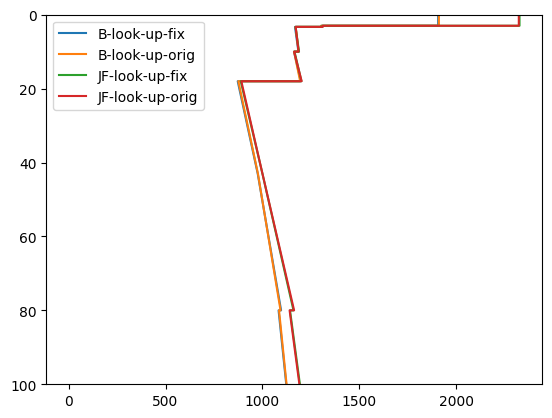

In [28]:
plt.plot(DMM_anelastic_B_new_lu[:,2],DMM_anelastic_B_new_lu[:,0],label='B-look-up-fix')
plt.plot(DMM_anelastic_B_new[:,2],DMM_anelastic_B_new_lu[:,0],label='B-look-up-orig')
plt.plot(DMM_anelastic_JF_new_lu[:,2],DMM_anelastic_JF_new_lu[:,0],label='JF-look-up-fix')
plt.plot(DMM_anelastic_JF_new[:,2],DMM_anelastic_JF_new_lu[:,0],label='JF-look-up-orig')
plt.ylim(100,0)

plt.legend()

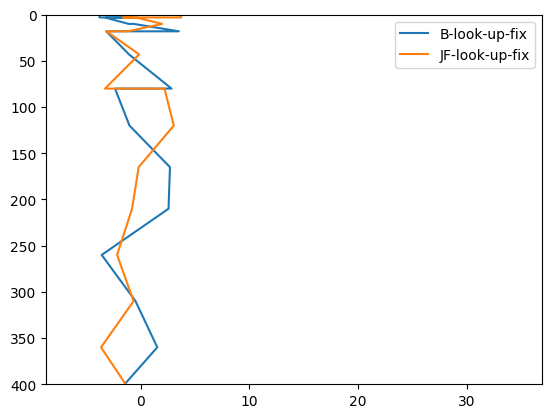

In [29]:
ind=2
plt.plot(DMM_anelastic_B_new_lu[:,ind]-DMM_anelastic_B_new[:,ind],DMM_anelastic_B_new_lu[:,0],label='B-look-up-fix')
plt.plot(DMM_anelastic_JF_new_lu[:,ind]-DMM_anelastic_JF_new[:,ind],DMM_anelastic_JF_new_lu[:,0],label='JF-look-up-fix')
plt.ylim(400,0)

plt.legend()


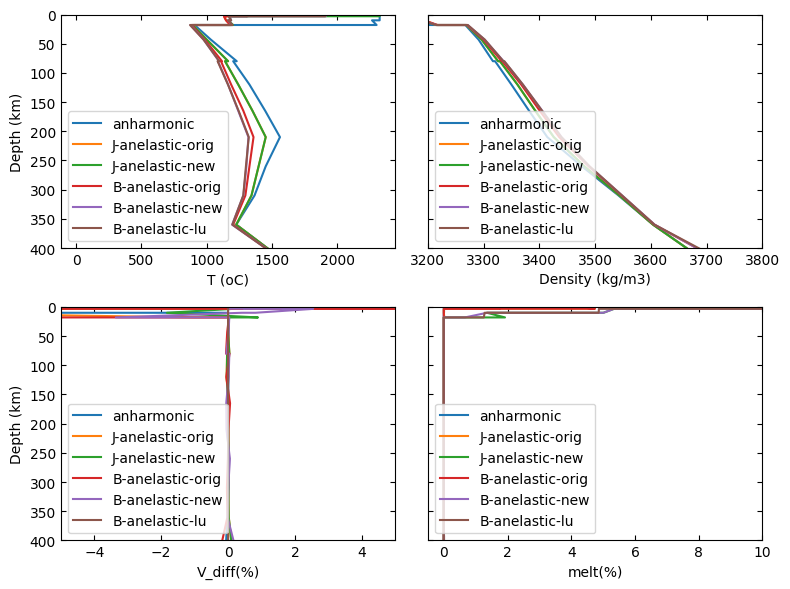

In [31]:
#Output: [depth,P_out,Temperature_out,Density_out,Vp_out,Vs_out,diff_Vp,melt_out)
fig, axs = plt.subplots(2, 2, figsize=(8,6),sharey=True)
axes = axs.ravel()

# Define indices to plot for each panel
indices = [2, 3, 6, 7]
# Define your list of X-axis names here (make sure it matches the length of indices)
x_labels = ['T (oC)', 'Density (kg/m3)', 'V_diff(%)', 'melt(%)']
# Loop through each panel index and its corresponding axis
for i, idx in enumerate(indices):
    ax = axes[i]
    
    # Plot datasets for the current column index
    ax.plot(DMM_anhar[:, idx], DMM_anhar[:, 0], label='anharmonic')
    ax.plot(DMM_anelastic_JF_orig[:, idx], DMM_anhar[:, 0], label='J-anelastic-orig')
    ax.plot(DMM_anelastic_JF_new[:, idx], DMM_anhar[:, 0], label='J-anelastic-new')
    ax.plot(DMM_anelastic_B_orig[:, idx], DMM_anhar[:, 0], label='B-anelastic-orig')
    ax.plot(DMM_anelastic_B_new[:, idx], DMM_anhar[:, 0], label='B-anelastic-new')
    ax.plot(DMM_anelastic_B_new_lu[:, idx], DMM_anhar[:, 0], label='B-anelastic-lu')
    
    # Customisations per panel
    #ax.set_title(x_labels[i])
    ax.set_xlabel(x_labels[i])  # Pulls the corresponding label from your list
    ax.tick_params(direction='in', top=True, right=True)
    ax.legend(loc='lower left')


# --- Specific Y-Axis Setup ---
# Set the inverted depth scale (automatically updates all due to sharey=True)
axes[0].set_ylim(400, 0) 

# Add Y-labels only to the leftmost panels (Column 0)
axs[0, 0].set_ylabel('Depth (km)')
axs[1, 0].set_ylabel('Depth (km)')

# Place a single legend on one of the panels (e.g., bottom-right)
axes[1].set_xlim(3200,3800)
axes[2].set_xlim(-5,5)
axes[3].set_xlim(-0.5,10)
plt.tight_layout()
plt.show()


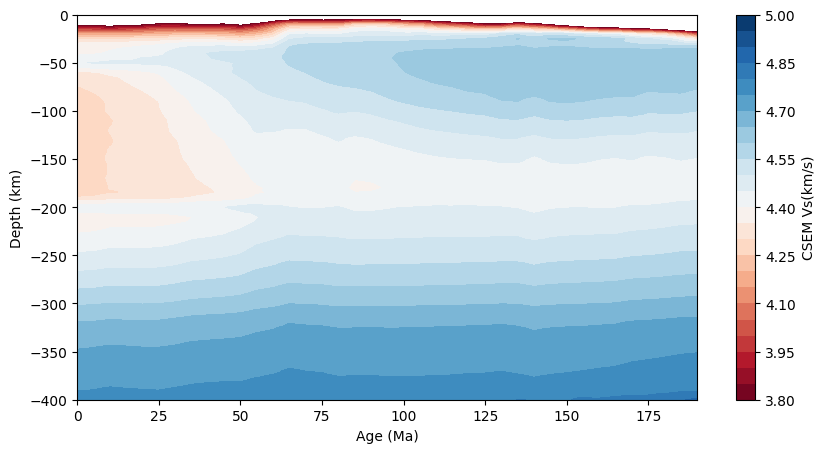

In [33]:
tomo_NA_stack = np.loadtxt('./../data_tomo/NA_age_vel_stack.dat',comments='#')
tri = Triangulation(tomo_NA_stack[:,0],-tomo_NA_stack[:, 1])
fig, ax = plt.subplots(1, 1, sharex=True, sharey=True,figsize=(10,5))
m_v_in = ax.tricontourf(tri, tomo_NA_stack[:, 2],cmap='RdBu',levels=np.arange(3.8,5,0.05))
ax.set_ylim([-400,0])
ax.set_xlabel('Age (Ma)')
ax.set_ylabel('Depth (km)')
fig.colorbar(m_v_in, ax=ax, label='CSEM Vs(km/s)', orientation='vertical')

In [34]:
OC_anelastic_JF_orig= vel_vs_to_temp_prop_out(tomo_NA_stack[:,1],tomo_NA_stack[:,2],TABLE_DMM_corr_JF_mc_orig);
OC_anelastic_JF_new= vel_vs_to_temp_prop_out(tomo_NA_stack[:,1],tomo_NA_stack[:,2],TABLE_DMM_corr_JF_mc_new);
OC_anelastic_B_orig= vel_vs_to_temp_prop_out(tomo_NA_stack[:,1],tomo_NA_stack[:,2],TABLE_DMM_corr_B_mc_orig);
OC_anelastic_B_new= vel_vs_to_temp_prop_out(tomo_NA_stack[:,1],tomo_NA_stack[:,2],TABLE_DMM_corr_B_mc_new);
OC_anelastic_B_new_lu= vel_vs_to_temp_prop_out_new(tomo_NA_stack[:,1],tomo_NA_stack[:,2],TABLE_DMM_corr_B_mc_new);
OC_anelastic_JF_new_lu= vel_vs_to_temp_prop_out_new(tomo_NA_stack[:,1],tomo_NA_stack[:,2],TABLE_DMM_corr_B_mc_new);

OC_anhar= vel_vs_to_temp_prop_out(tomo_NA_stack[:,1],tomo_NA_stack[:,2],TABLE_DMM);

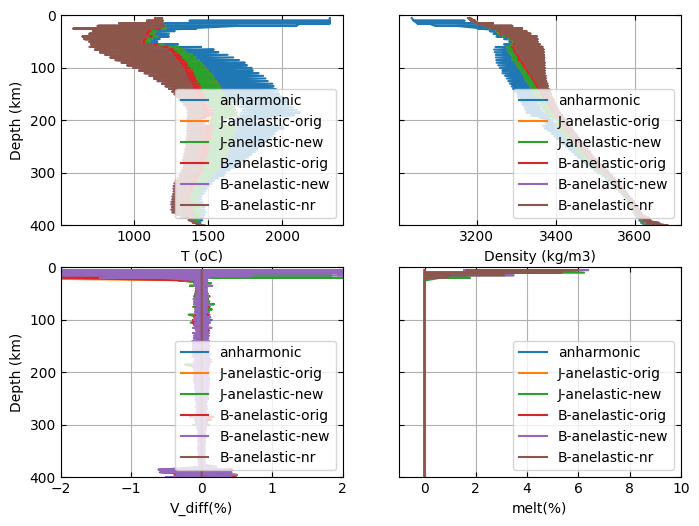

In [35]:
#Output: [depth,P_out,Temperature_out,Density_out,Vp_out,Vs_out,diff_Vp,melt_out)
fig, axs = plt.subplots(2, 2, figsize=(8,6),sharey=True)
axes = axs.ravel()

# Define indices to plot for each panel
indices = [2, 3, 6, 7]
# Define your list of X-axis names here (make sure it matches the length of indices)
x_labels = ['T (oC)', 'Density (kg/m3)', 'V_diff(%)', 'melt(%)']
# Loop through each panel index and its corresponding axis
for i, idx in enumerate(indices):
    ax = axes[i]
    
    # Plot datasets for the current column index
    ax.plot(OC_anhar[:, idx], OC_anhar[:, 0], label='anharmonic')
    ax.plot(OC_anelastic_JF_orig[:, idx], OC_anhar[:, 0], label='J-anelastic-orig')
    ax.plot(OC_anelastic_JF_new[:, idx], OC_anhar[:, 0], label='J-anelastic-new')
    ax.plot(OC_anelastic_B_orig[:, idx], OC_anhar[:, 0], label='B-anelastic-orig')
    ax.plot(OC_anelastic_B_new[:, idx], OC_anhar[:, 0], label='B-anelastic-new')
    ax.plot(OC_anelastic_B_new_lu[:, idx], OC_anhar[:, 0], label='B-anelastic-nr')

    # Customisations per panel
    #ax.set_title(x_labels[i])
    ax.set_xlabel(x_labels[i])  # Pulls the corresponding label from your list
    ax.tick_params(direction='in', top=True, right=True)
    ax.legend(loc='lower right')
    ax.grid()

# --- Specific Y-Axis Setup ---
# Set the inverted depth scale (automatically updates all due to sharey=True)
axes[0].set_ylim(400, 0) 

# Add Y-labels only to the leftmost panels (Column 0)
axs[0, 0].set_ylabel('Depth (km)')
axs[1, 0].set_ylabel('Depth (km)')
# Place a single legend on one of the panels (e.g., bottom-right)
axes[2].set_xlim(-2,2)
axes[3].set_xlim(-1,10)
#plt.tight_layout()
plt.show()


# Difference beacuse of the correction and alelasticity

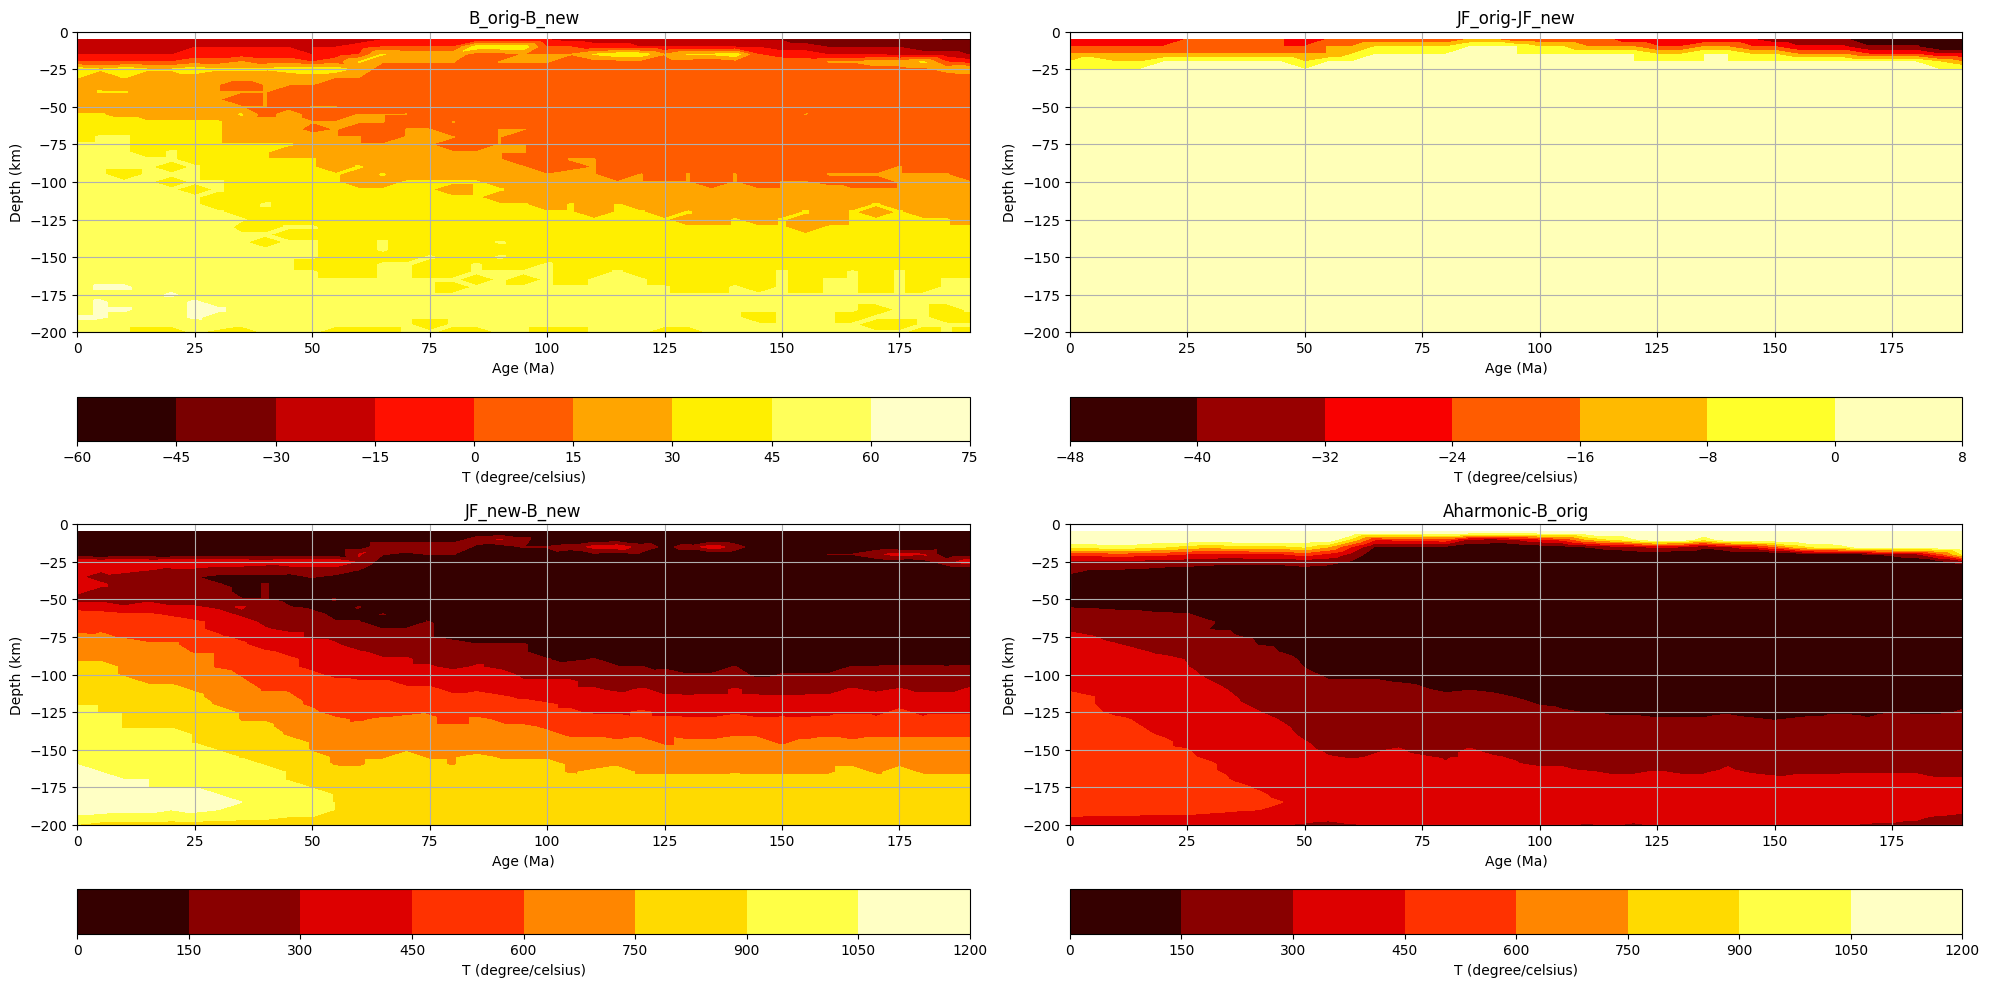

In [37]:
tri = Triangulation(tomo_NA_stack[:,0],-tomo_NA_stack[:, 1])
fig, ax = plt.subplots(2, 2,sharex=False, sharey=False,figsize=(20,10))
m_v_in_gibbs = ax[0,0].tricontourf(tri, OC_anelastic_B_orig[:,2]-OC_anelastic_B_new[:,2],cmap='hot')#,levels=np.arange(-500,500,50))
#m_v_in_gibbs = ax[0].tricontour(tri, out_gibbs[:,1],cmap='hot',levels=np.arange(0,1400,100))
m_v_in_goes = ax[0,1].tricontourf(tri, OC_anelastic_JF_orig[:,2]-OC_anelastic_JF_new[:,2],cmap='hot')#,levels=np.arange(-500,500,50))
#m_v_in_goes = ax[1].tricontour(tri, MC.Result_T-273,cmap='hot',levels=np.arange(0,1400,100))
m_v_in_HS = ax[1,0].tricontourf(tri, OC_anelastic_JF_new[:,2]-OC_anelastic_B_new[:,2],cmap='hot')#,levels=np.arange(-500,500,50))
#m_v_in_HS = ax[2].tricontour(tri, T_half_space,cmap='hot',levels=np.arange(0,1400,100))
m_v_in_HS = ax[1,1].tricontourf(tri, OC_anhar[:,2]-OC_anelastic_B_orig[:,2],cmap='hot')#,levels=np.arange(-500,500,50))
for a in ax.flatten():
        #a.set_aspect('equal')
        a.set_ylim([-200,0])
        a.set_xlabel('Age (Ma)')
        a.set_ylabel('Depth (km)')
        a.set_title('')
        a.grid()
fig.colorbar(m_v_in_gibbs, ax=ax[0,0], label='T (degree/celsius)', orientation='horizontal')
fig.colorbar(m_v_in_goes, ax=ax[0,1], label='T (degree/celsius)', orientation='horizontal')
fig.colorbar(m_v_in_HS, ax=ax[1,0], label='T (degree/celsius)', orientation='horizontal')
fig.colorbar(m_v_in_HS, ax=ax[1,1], label='T (degree/celsius)', orientation='horizontal')
ax[0,0].set_title('B_orig-B_new')
ax[0,1].set_title('JF_orig-JF_new')
ax[1,0].set_title('JF_new-B_new')
ax[1,1].set_title('Aharmonic-B_orig')
plt.tight_layout()
#fig.colorbar(m_t_out, ax=ax[2], label='Temperature (Celcius)', orientation='horizontal')
#fig.colorbar(m_dens_out, ax=ax[3], label='Density (g/cm3)', orientation='horizontal')
#fig.suptitle(title, fontsize=16)
#ax.set_ylim([-400,0])
#ax.set_xlabel('Distance (km)')
#ax.set_ylabel('Depth (km)')
#fig.colorbar(m_v_in_gibbs, ax=ax[0], label='Temperature (degree/celcius)', orientation='vertical')

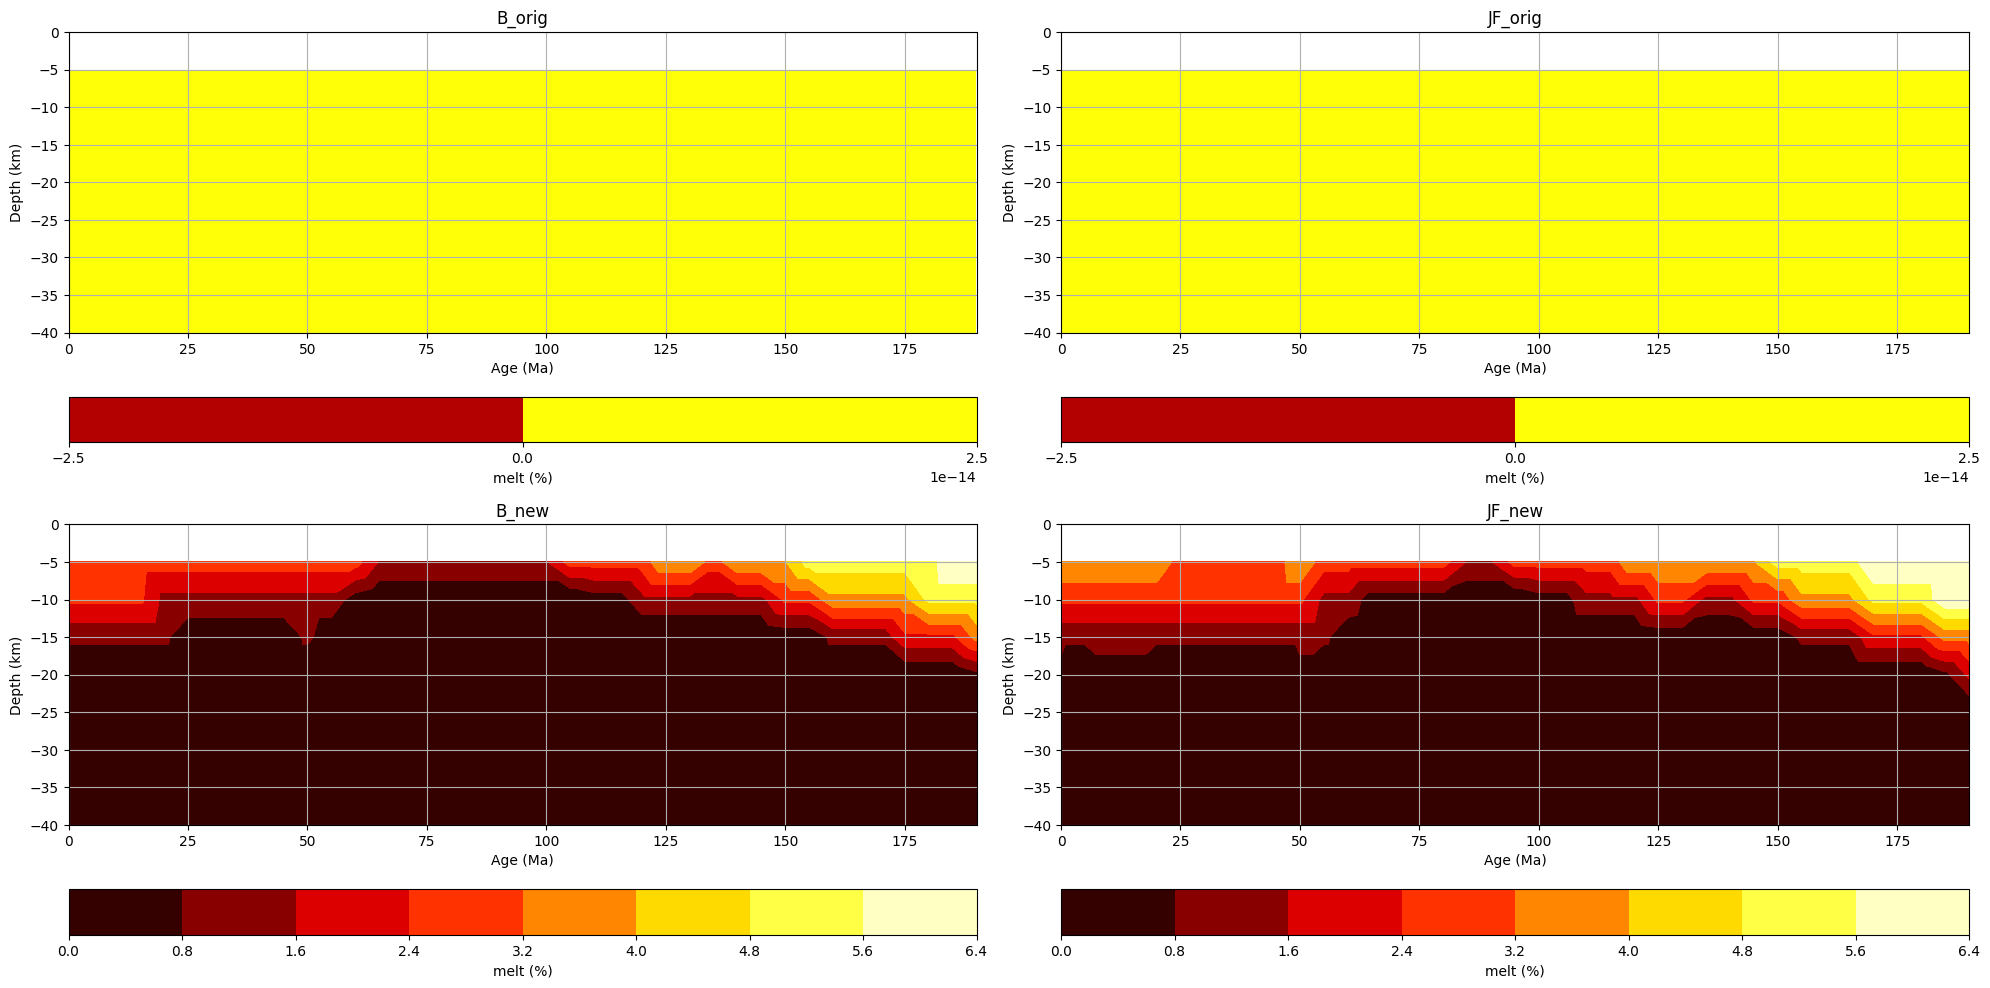

In [38]:
tri = Triangulation(tomo_NA_stack[:,0],-tomo_NA_stack[:, 1])
fig, ax = plt.subplots(2, 2,sharex=False, sharey=False,figsize=(20,10))
m_v_in_gibbs = ax[0,0].tricontourf(tri, OC_anelastic_B_orig[:,-1],cmap='hot')#,levels=np.arange(-500,500,50))
#m_v_in_gibbs = ax[0].tricontour(tri, out_gibbs[:,1],cmap='hot',levels=np.arange(0,1400,100))
m_v_in_goes = ax[0,1].tricontourf(tri, OC_anelastic_JF_orig[:,-1],cmap='hot')#,levels=np.arange(-500,500,50))
#m_v_in_goes = ax[1].tricontour(tri, MC.Result_T-273,cmap='hot',levels=np.arange(0,1400,100))
m_v_in_HS = ax[1,0].tricontourf(tri, OC_anelastic_B_new[:,-1],cmap='hot')#,levels=np.arange(-500,500,50))
#m_v_in_HS = ax[2].tricontour(tri, T_half_space,cmap='hot',levels=np.arange(0,1400,100))
m_v_in_HS = ax[1,1].tricontourf(tri, OC_anelastic_JF_new[:,-1],cmap='hot')#,levels=np.arange(-500,500,50))
for a in ax.flatten():
        #a.set_aspect('equal')
        a.set_ylim([-40,0])
        a.set_xlabel('Age (Ma)')
        a.set_ylabel('Depth (km)')
        a.set_title('')
        a.grid()
fig.colorbar(m_v_in_gibbs, ax=ax[0,0], label='melt (%)', orientation='horizontal')
fig.colorbar(m_v_in_goes, ax=ax[0,1], label='melt (%)', orientation='horizontal')
fig.colorbar(m_v_in_HS, ax=ax[1,0], label='melt (%)', orientation='horizontal')
fig.colorbar(m_v_in_HS, ax=ax[1,1], label='melt (%)', orientation='horizontal')
ax[0,0].set_title('B_orig')
ax[0,1].set_title('JF_orig')
ax[1,0].set_title('B_new')
ax[1,1].set_title('JF_new')
plt.tight_layout()
#fig.colorbar(m_t_out, ax=ax[2], label='Temperature (Celcius)', orientation='horizontal')
#fig.colorbar(m_dens_out, ax=ax[3], label='Density (g/cm3)', orientation='horizontal')
#fig.suptitle(title, fontsize=16)
#ax.set_ylim([-400,0])
#ax.set_xlabel('Distance (km)')
#ax.set_ylabel('Depth (km)')
#fig.colorbar(m_v_in_gibbs, ax=ax[0], label='Temperature (degree/celcius)', orientation='vertical')

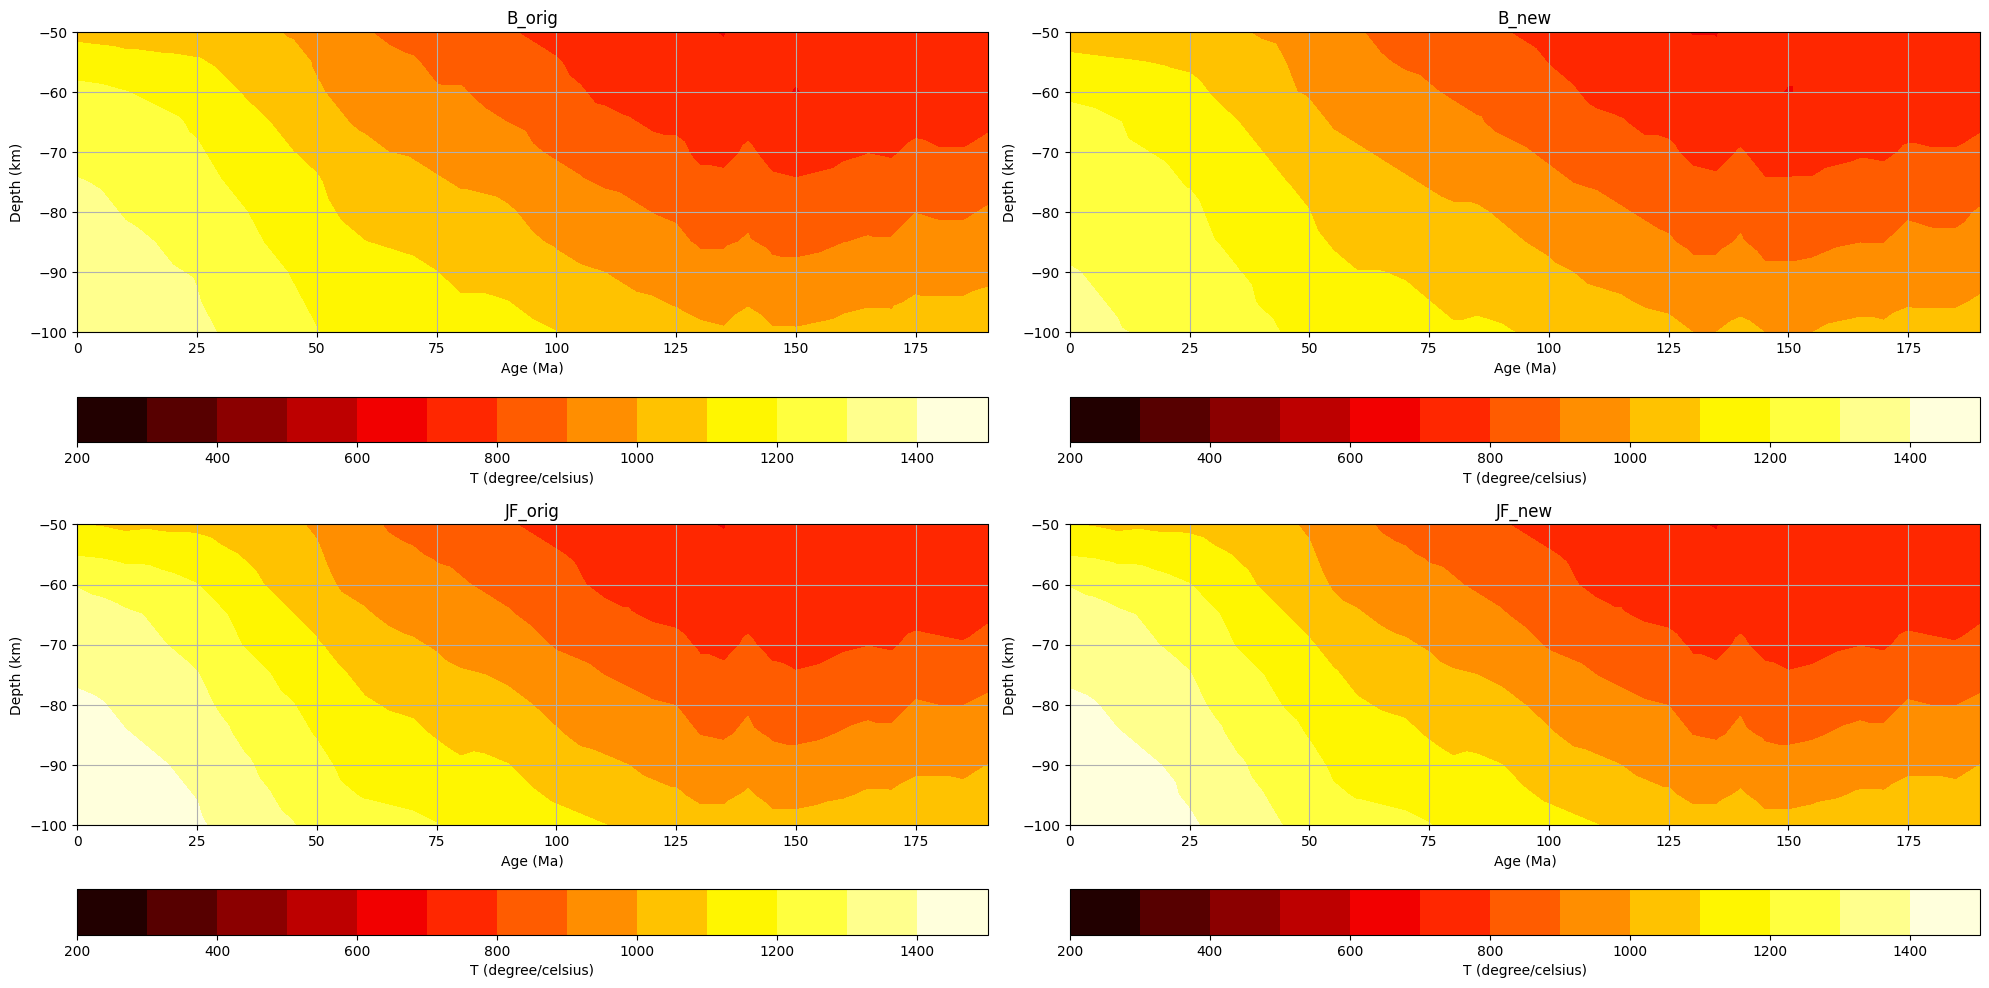

In [39]:
tri = Triangulation(tomo_NA_stack[:,0],-tomo_NA_stack[:, 1])
fig, ax = plt.subplots(2, 2,sharex=False, sharey=False,figsize=(20,10))
m_v_in_gibbs = ax[0,0].tricontourf(tri, OC_anelastic_B_orig[:,2],cmap='hot',levels=np.arange(200,1600,100))
#m_v_in_gibbs = ax[0].tricontour(tri, out_gibbs[:,1],cmap='hot',levels=np.arange(0,1400,100))
m_v_in_goes = ax[0,1].tricontourf(tri, OC_anelastic_B_new[:,2],cmap='hot',levels=np.arange(200,1600,100))
#m_v_in_goes = ax[1].tricontour(tri, MC.Result_T-273,cmap='hot',levels=np.arange(0,1400,100))
m_v_in_HS = ax[1,0].tricontourf(tri, OC_anelastic_JF_orig[:,2],cmap='hot',levels=np.arange(200,1600,100))#,levels=np.arange(-500,500,50))
#m_v_in_HS = ax[2].tricontour(tri, T_half_space,cmap='hot',levels=np.arange(0,1400,100))
m_v_in_HS = ax[1,1].tricontourf(tri,OC_anelastic_JF_new[:,2],cmap='hot',levels=np.arange(200,1600,100))#,levels=np.arange(-500,500,50))
for a in ax.flatten():
        #a.set_aspect('equal')
        a.set_ylim([-100,-50])
        a.set_xlabel('Age (Ma)')
        a.set_ylabel('Depth (km)')
        a.set_title('')
        a.grid()
    
fig.colorbar(m_v_in_gibbs, ax=ax[0,0], label='T (degree/celsius)', orientation='horizontal')
fig.colorbar(m_v_in_goes, ax=ax[0,1], label='T (degree/celsius)', orientation='horizontal')
fig.colorbar(m_v_in_HS, ax=ax[1,0], label='T (degree/celsius)', orientation='horizontal')
fig.colorbar(m_v_in_HS, ax=ax[1,1], label='T (degree/celsius)', orientation='horizontal')
ax[0,0].set_title('B_orig')
ax[0,1].set_title('B_new')
ax[1,0].set_title('JF_orig')
ax[1,1].set_title('JF_new')
plt.tight_layout()
#fig.colorbar(m_t_out, ax=ax[2], label='Temperature (Celcius)', orientation='horizontal')
#fig.colorbar(m_dens_out, ax=ax[3], label='Density (g/cm3)', orientation='horizontal')
#fig.suptitle(title, fontsize=16)
#ax.set_ylim([-400,0])
#ax.set_xlabel('Distance (km)')
#ax.set_ylabel('Depth (km)')
#fig.colorbar(m_v_in_gibbs, ax=ax[0], label='Temperature (degree/celcius)', orientation='vertical')

# look-up effect

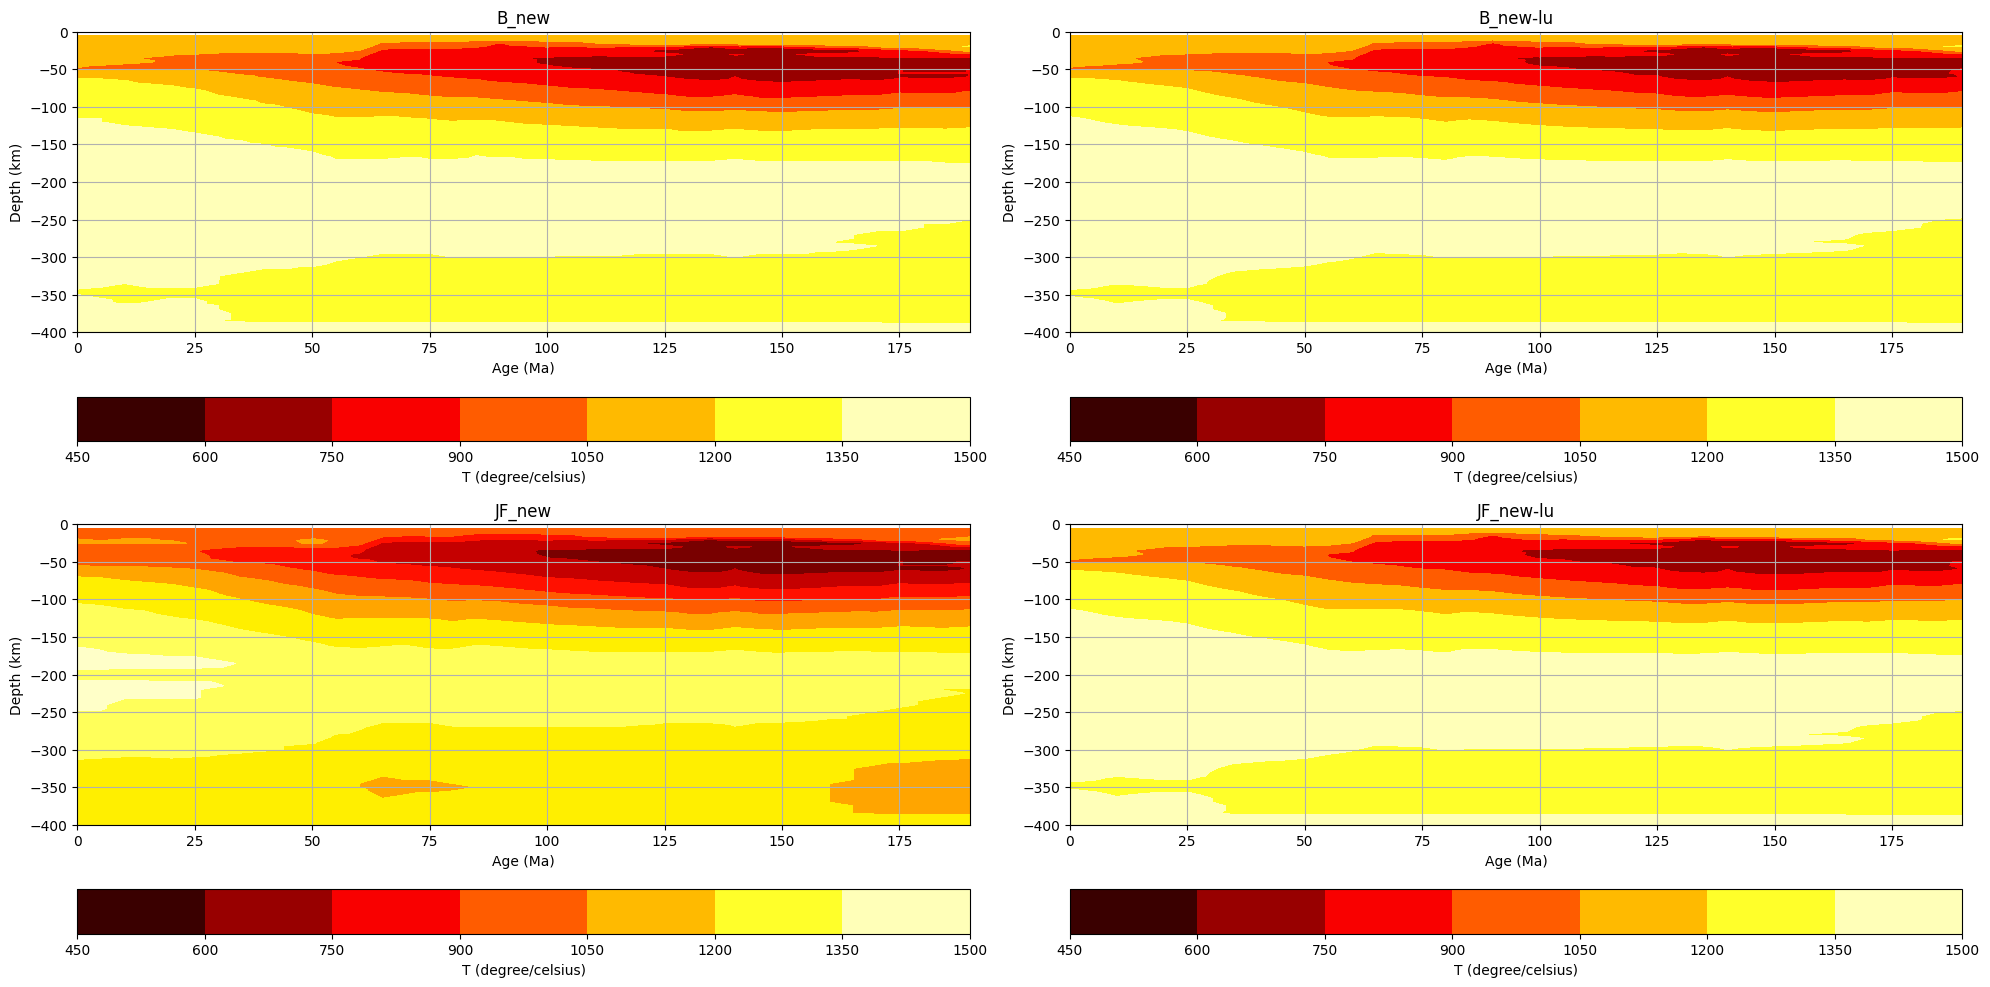

In [40]:
ind=2
tri = Triangulation(tomo_NA_stack[:,0],-tomo_NA_stack[:, 1])
fig, ax = plt.subplots(2, 2,sharex=False, sharey=False,figsize=(20,10))
m_v_in_gibbs = ax[0,0].tricontourf(tri, OC_anelastic_B_new[:,ind],cmap='hot')#,levels=np.arange(200,1600,100))
#m_v_in_gibbs = ax[0].tricontour(tri, out_gibbs[:,1],cmap='hot',levels=np.arange(0,1400,100))
m_v_in_goes = ax[0,1].tricontourf(tri, OC_anelastic_B_new_lu[:,ind],cmap='hot')#,levels=np.arange(200,1600,100))
#m_v_in_goes = ax[1].tricontour(tri, MC.Result_T-273,cmap='hot',levels=np.arange(0,1400,100))
m_v_in_HS = ax[1,0].tricontourf(tri, OC_anelastic_JF_new[:,ind],cmap='hot')#,levels=np.arange(200,1600,100))#,levels=np.arange(-500,500,50))
#m_v_in_HS = ax[2].tricontour(tri, T_half_space,cmap='hot',levels=np.arange(0,1400,100))
m_v_in_HS = ax[1,1].tricontourf(tri,OC_anelastic_JF_new_lu[:,ind],cmap='hot')#,levels=np.arange(200,1600,100))#,levels=np.arange(-500,500,50))
for a in ax.flatten():
        #a.set_aspect('equal')
        a.set_ylim([-400,0])
        a.set_xlabel('Age (Ma)')
        a.set_ylabel('Depth (km)')
        a.set_title('')
        a.grid()
    
fig.colorbar(m_v_in_gibbs, ax=ax[0,0], label='T (degree/celsius)', orientation='horizontal')
fig.colorbar(m_v_in_goes, ax=ax[0,1], label='T (degree/celsius)', orientation='horizontal')
fig.colorbar(m_v_in_HS, ax=ax[1,0], label='T (degree/celsius)', orientation='horizontal')
fig.colorbar(m_v_in_HS, ax=ax[1,1], label='T (degree/celsius)', orientation='horizontal')
ax[0,0].set_title('B_new')
ax[0,1].set_title('B_new-lu')
ax[1,0].set_title('JF_new')
ax[1,1].set_title('JF_new-lu')
plt.tight_layout()
#fig.colorbar(m_t_out, ax=ax[2], label='Temperature (Celcius)', orientation='horizontal')
#fig.colorbar(m_dens_out, ax=ax[3], label='Density (g/cm3)', orientation='horizontal')
#fig.suptitle(title, fontsize=16)
#ax.set_ylim([-400,0])
#ax.set_xlabel('Distance (km)')
#ax.set_ylabel('Depth (km)')
#fig.colorbar(m_v_in_gibbs, ax=ax[0], label='Temperature (degree/celcius)', orientation='vertical')

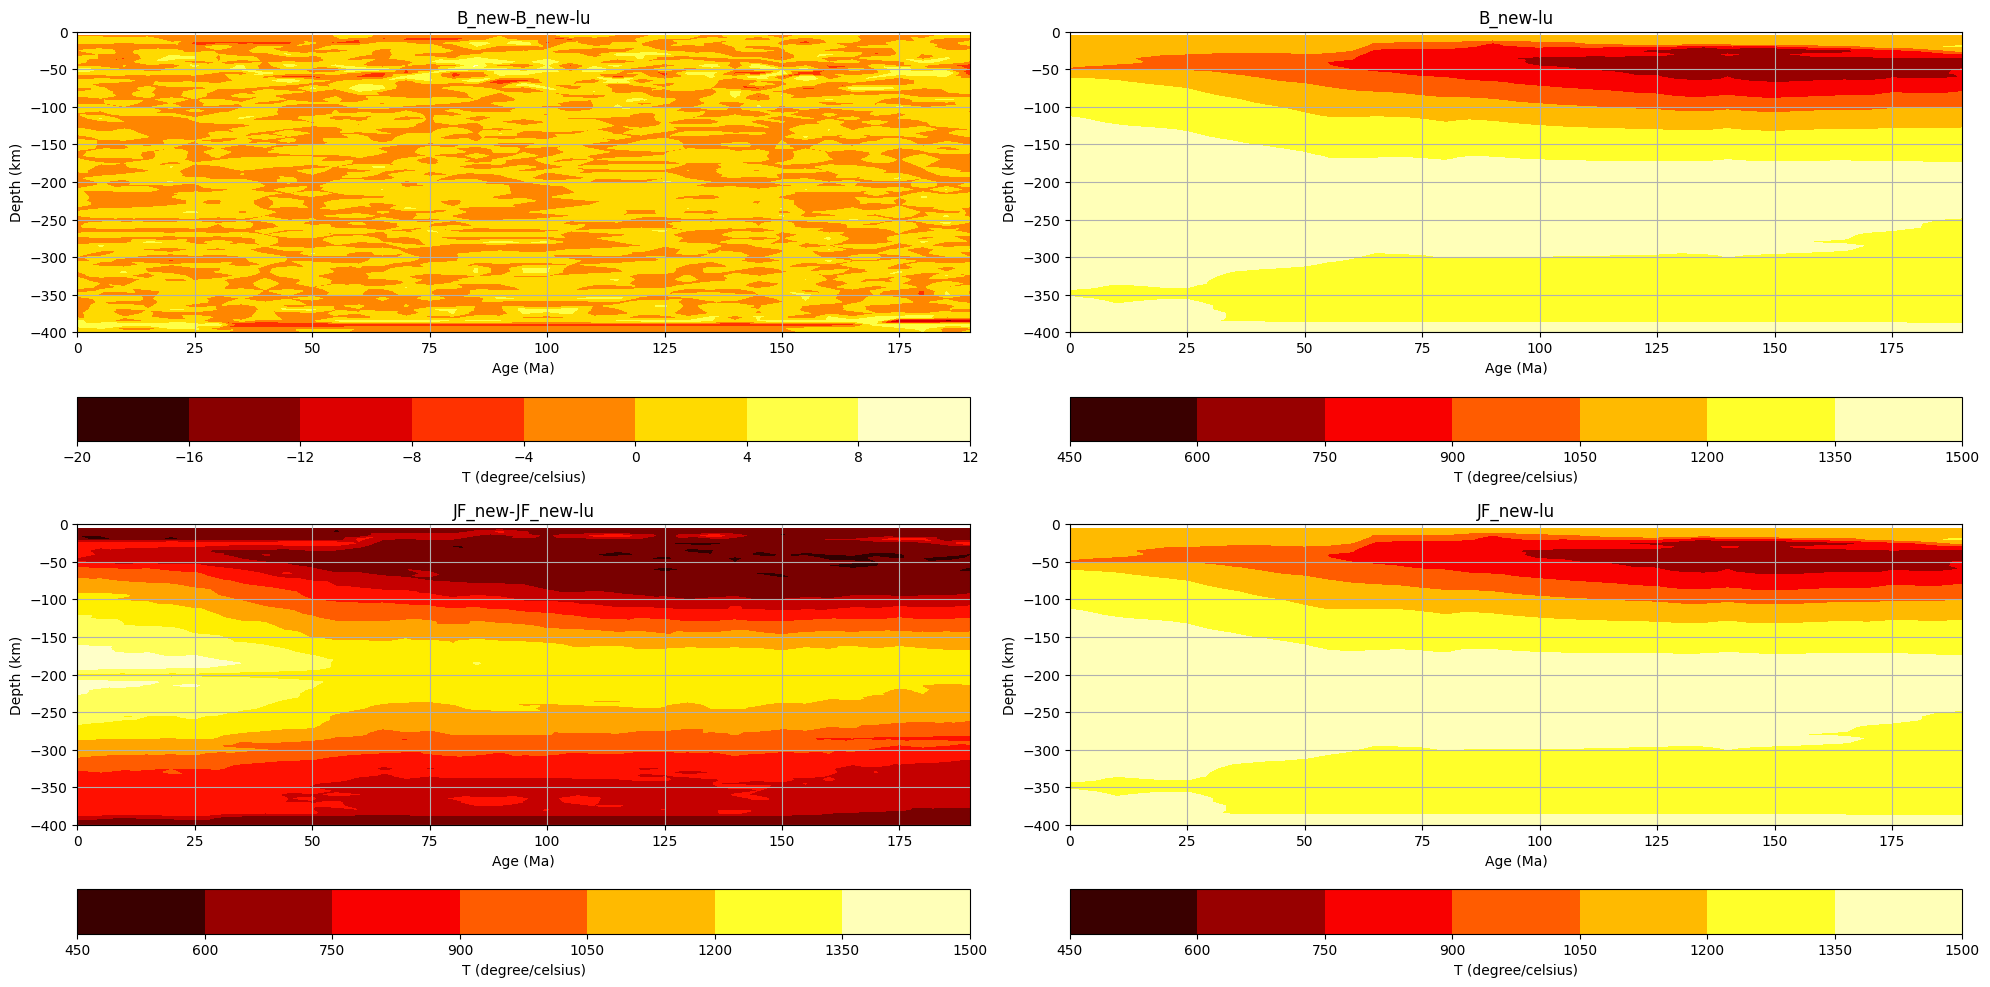

In [41]:
ind=2
tri = Triangulation(tomo_NA_stack[:,0],-tomo_NA_stack[:, 1])
fig, ax = plt.subplots(2, 2,sharex=False, sharey=False,figsize=(20,10))
m_v_in_gibbs = ax[0,0].tricontourf(tri, OC_anelastic_B_new[:,ind]-OC_anelastic_B_new_lu[:,ind],cmap='hot')#,levels=np.arange(200,1600,100))
#m_v_in_gibbs = ax[0].tricontour(tri, out_gibbs[:,1],cmap='hot',levels=np.arange(0,1400,100))
m_v_in_goes = ax[0,1].tricontourf(tri, OC_anelastic_B_new_lu[:,ind],cmap='hot')#,levels=np.arange(200,1600,100))
#m_v_in_goes = ax[1].tricontour(tri, MC.Result_T-273,cmap='hot',levels=np.arange(0,1400,100))
m_v_in_HS = ax[1,0].tricontourf(tri, OC_anelastic_JF_new[:,ind]-OC_anelastic_JF_new_lu[:,ind],cmap='hot')#,levels=np.arange(200,1600,100))#,levels=np.arange(-500,500,50))
#m_v_in_HS = ax[2].tricontour(tri, T_half_space,cmap='hot',levels=np.arange(0,1400,100))
m_v_in_HS = ax[1,1].tricontourf(tri,OC_anelastic_JF_new_lu[:,ind],cmap='hot')#,levels=np.arange(200,1600,100))#,levels=np.arange(-500,500,50))
for a in ax.flatten():
        #a.set_aspect('equal')
        a.set_ylim([-400,0])
        a.set_xlabel('Age (Ma)')
        a.set_ylabel('Depth (km)')
        a.set_title('')
        a.grid()
    
fig.colorbar(m_v_in_gibbs, ax=ax[0,0], label='T (degree/celsius)', orientation='horizontal')
fig.colorbar(m_v_in_goes, ax=ax[0,1], label='T (degree/celsius)', orientation='horizontal')
fig.colorbar(m_v_in_HS, ax=ax[1,0], label='T (degree/celsius)', orientation='horizontal')
fig.colorbar(m_v_in_HS, ax=ax[1,1], label='T (degree/celsius)', orientation='horizontal')
ax[0,0].set_title('B_new-B_new-lu')
ax[0,1].set_title('B_new-lu')
ax[1,0].set_title('JF_new-JF_new-lu')
ax[1,1].set_title('JF_new-lu')
plt.tight_layout()
#fig.colorbar(m_t_out, ax=ax[2], label='Temperature (Celcius)', orientation='horizontal')
#fig.colorbar(m_dens_out, ax=ax[3], label='Density (g/cm3)', orientation='horizontal')
#fig.suptitle(title, fontsize=16)
#ax.set_ylim([-400,0])
#ax.set_xlabel('Distance (km)')
#ax.set_ylabel('Depth (km)')
#fig.colorbar(m_v_in_gibbs, ax=ax[0], label='Temperature (degree/celcius)', orientation='vertical')

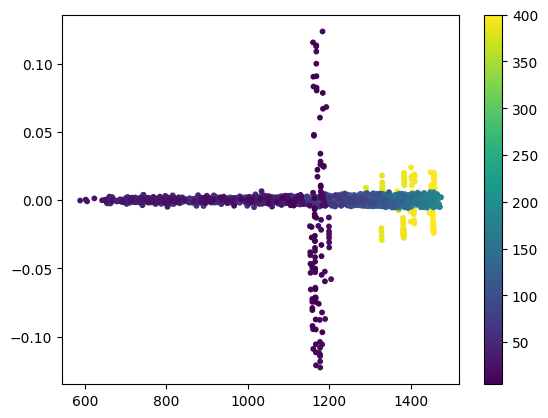

In [50]:
data=OC_anelastic_B_new_lu
plt.scatter(x=data[:,2],y=data[:,-3]-OC_anelastic_B_new,s=10,c=data[:,0])

data=OC_anelastic_B_new
plt.scatter(x=data[:,2],y=data[:,-3],s=1,c=data[:,0])
plt.colorbar()

NameError: name 'DMM' is not defined

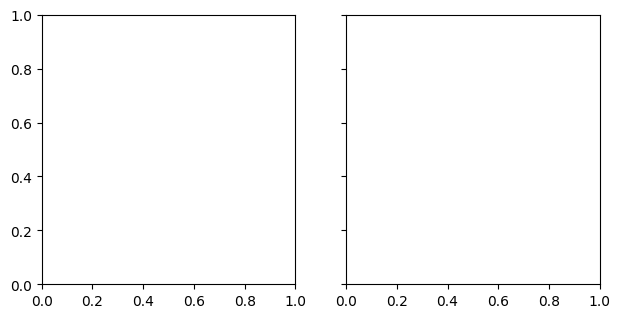

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.5), sharey=True)

ax0 = axes[0]
# Plotting profiles
ax0.plot(DMM[:, 2], DMM[:, 0], label='DMM')
ax0.plot(Tc1[:, 2], Tc1[:, 0], label='Tc1')
ax0.plot(Pr1[:, 2], Pr1[:, 0], label='Pr1')
ax0.plot(Arc1[:, 2], Arc1[:, 0], label='Arc1')
# Formatting panel A
ax0.set_xlim(600, 1500)
ax0.set_xlabel('Temperature (°C)')
ax0.set_ylabel('Depth (km)')
ax0.legend(loc='lower left')
ax0.text(-0.15, 1.05, 'a', transform=ax0.transAxes, fontsize=10, fontweight='bold', va='top') # Nature panel label

ax1 = axes[1]
# Plotting profiles
ax1.plot(DMM[:, 3], DMM[:, 0], label='DMM')
ax1.plot(Tc1[:, 3], Tc1[:, 0], label='Tc1')
ax1.plot(Pr1[:, 3], Pr1[:, 0], label='Pr1')
ax1.plot(Arc1[:, 3], Arc1[:, 0], label='Arc1')
# Formatting panel B
ax1.set_xlim(3000, 3600)
ax1.set_xlabel('Density (kg/m³)')
ax1.text(-0.05, 1.05, 'b', transform=ax1.transAxes, fontsize=10, fontweight='bold', va='top')
# Only one legend is needed since the labels/colors match across panels
ax1.legend(loc='lower left')

for ax in axes:
    ax.set_ylim(400, 0) # Keeps the inverted depth scale
    ax.tick_params(direction='in', top=True, right=True) # Nature-style interior ticks

plt.tight_layout()
plt.show()

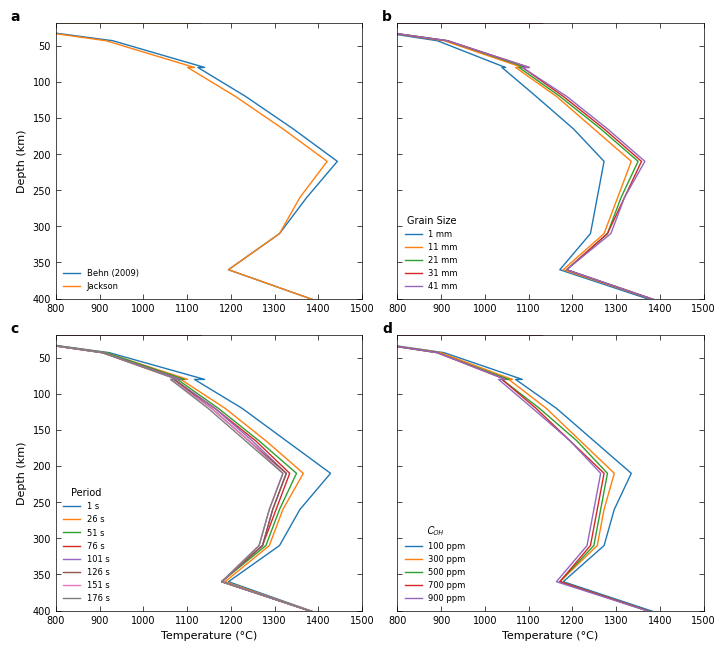

In [37]:
# Create a 2x2 grid sharing the depth (y) axis across columns
fig, axes = plt.subplots(2, 2, figsize=(7.2, 6.5), sharey=True)

# Unpack axes for easier readability
((ax_a, ax_b), (ax_c, ax_d)) = axes

# Global baseline constants
grain_size_base = 10
period_base = 100
coh_base = 100
# ----------------------------------------------------
# Panel A: Model Comparison (Behn vs Jackson)
# ----------------------------------------------------
# Behn 2009 Profile (table, grain_size, period, COH)
TABLE_DMM_corr = lib.mantle_melt_atten_correction_Behn2009(table_DMM, grain_size_base, period_base, 1)
PUM_behn = lib.vel_vs_to_temp_prop_out(tomo_in[:, 0], tomo_in[:, 3], TABLE_DMM_corr)
ax_a.plot(PUM_behn[:, 2], PUM_behn[:, 0], label='Behn (2009)')
# Jackson Profile (table, grain_size, period)
TABLE_PUM_corr = lib.mantle_melt_atten_correction(table_PUM, grain_size_base, period_base)
PUM_jack = lib.vel_vs_to_temp_prop_out(tomo_in[:, 0], tomo_in[:, 3], TABLE_PUM_corr)
ax_a.plot(PUM_jack[:, 2], PUM_jack[:, 0], label='Jackson')

ax_a.legend(loc='lower left')
ax_a.set_ylabel('Depth (km)')
ax_a.text(-0.15, 1.05, 'a', transform=ax_a.transAxes, fontsize=10, fontweight='bold', va='top')

# ----------------------------------------------------
# Panel B: Sensitivity to Grain Size
# ----------------------------------------------------
for grain_size in range(1, 50, 10):
    # Fixed period=100, COH=100 passed positionally
    TABLE_PUM_corr = lib.mantle_melt_atten_correction_Behn2009(table_PUM, grain_size, 100, 100)
    DMM = lib.vel_vs_to_temp_prop_out(tomo_in[:, 0], tomo_in[:, 3], TABLE_PUM_corr)
    ax_b.plot(DMM[:, 2], DMM[:, 0], label=f'{grain_size} mm')
ax_b.legend(title='Grain Size', loc='lower left')
ax_b.text(-0.05, 1.05, 'b', transform=ax_b.transAxes, fontsize=10, fontweight='bold', va='top')
# ----------------------------------------------------
# Panel C: Sensitivity to Oscillation Period
# ----------------------------------------------------
for oscillation_period in range(1, 200, 25):
    # Fixed grain_size=grain_size_base, COH=100 passed positionally
    TABLE_PUM_corr = lib.mantle_melt_atten_correction_Behn2009(table_PUM, grain_size_base, oscillation_period, 100)
    DMM = lib.vel_vs_to_temp_prop_out(tomo_in[:, 0], tomo_in[:, 3], TABLE_PUM_corr)
    ax_c.plot(DMM[:, 2], DMM[:, 0], label=f'{oscillation_period} s')

ax_c.legend(title='Period', loc='lower left')
ax_c.set_xlabel('Temperature (°C)')
ax_c.set_ylabel('Depth (km)')
ax_c.text(-0.15, 1.05, 'c', transform=ax_c.transAxes, fontsize=10, fontweight='bold', va='top')


# ----------------------------------------------------
# Panel D: Sensitivity to Water Content (C_OH)
# ----------------------------------------------------
for COH in range(100, 1000, 200):
    # Fixed grain_size=grain_size_base, period=100 passed positionally
    TABLE_PUM_corr = lib.mantle_melt_atten_correction_Behn2009(table_PUM, grain_size_base, 100, COH)
    DMM = lib.vel_vs_to_temp_prop_out(tomo_in[:, 0], tomo_in[:, 3], TABLE_PUM_corr)
    ax_d.plot(DMM[:, 2], DMM[:, 0], label=f'{COH} ppm')

ax_d.legend(title=r'$C_{OH}$', loc='lower left')
ax_d.set_xlabel('Temperature (°C)')
ax_d.text(-0.05, 1.05, 'd', transform=ax_d.transAxes, fontsize=10, fontweight='bold', va='top')

# ----------------------------------------------------
# Global Layout Cleanups
# ----------------------------------------------------
for ax in axes.flat:
    ax.set_xlim(800, 1500)
    ax.set_ylim(400, 19)   # Inverted depth scale
    ax.tick_params(direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Effect of atten model

Text(0, 0.5, 'Depth (km)')

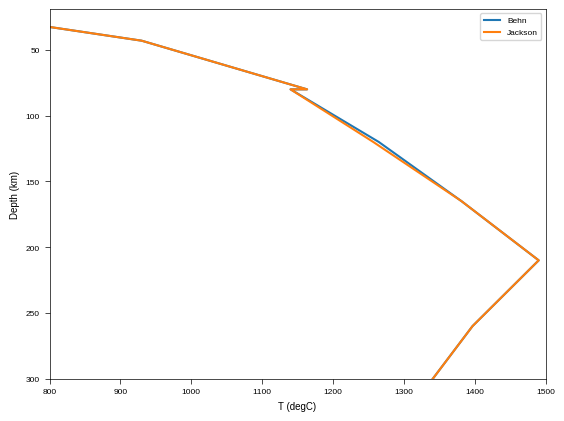

In [13]:
fig, axes = plt.subplots(1, 1, sharex=False, sharey=False)#, figsize=(20,15)) 
#
ax=axes

grain_size=10
oscillation_period=1
COH=1
TABLE_PUM_corr=lib.mantle_melt_atten_correction_Behn2009(table_PUM,grain_size,oscillation_period,COH)
PUM= lib.vel_vs_to_temp_prop_out(tomo_in[:,0],tomo_in[:,3],TABLE_PUM_corr);
use=PUM.copy()
xplot=2 #T
yplot=0 #d
ax.plot(use[:,xplot],use[:,yplot],label='Behn')

TABLE_PUM_corr=lib.mantle_melt_atten_correction(table_PUM,grain_size,oscillation_period)
PUM= lib.vel_vs_to_temp_prop_out(tomo_in[:,0],tomo_in[:,3],TABLE_PUM_corr);
use=PUM.copy()
xplot=2 #T
yplot=0 #d
ax.plot(use[:,xplot],use[:,yplot],label='Jackson')

ax.set_ylim(300,19)
ax.legend()
ax.set_xlim(800,1500)
ax.set_xlabel('T (degC)');ax.set_ylabel('Depth (km)')

# Effect of grain size


Text(0, 0.5, 'Depth (km)')

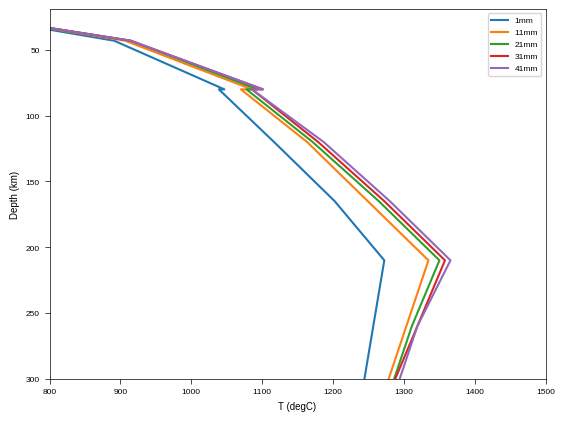

In [14]:
fig, axes = plt.subplots(1, 1, sharex=False, sharey=False)#, figsize=(20,15)) 
#
ax=axes
COH=100
oscillation_period=100
for grain_size in range(1,50,10):
    #PUM
    TABLE_PUM_corr=lib.mantle_melt_atten_correction_Behn2009(table_PUM,grain_size,oscillation_period,COH)
    PUM= lib.vel_vs_to_temp_prop_out(tomo_in[:,0],tomo_in[:,3],TABLE_PUM_corr);
    use=PUM.copy()
    xplot=2 #T
    yplot=0 #d
    ax.plot(use[:,xplot],use[:,yplot],label=str(grain_size)+'mm')

ax.set_ylim(300,19)
ax.legend()
ax.set_xlim(800,1500)
ax.set_xlabel('T (degC)');ax.set_ylabel('Depth (km)')


# Effect of Oscillation period

Text(0, 0.5, 'Depth (km)')

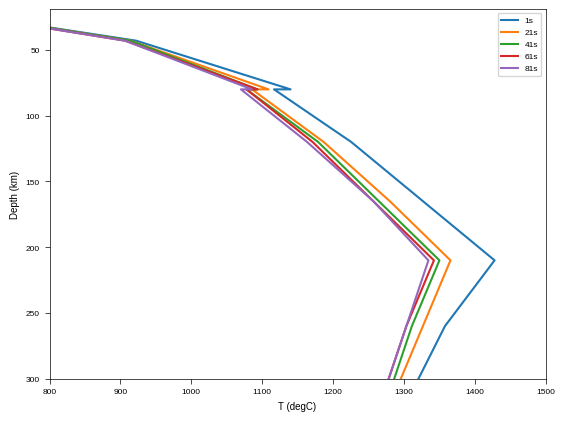

In [15]:
fig, axes = plt.subplots(1, 1, sharex=False, sharey=False)#, figsize=(20,15)) 
#
ax=axes
grain_size=10
COH=100
#oscillation_period=100
for oscillation_period in range(1,100,20):
    #PUM
    TABLE_PUM_corr=lib.mantle_melt_atten_correction_Behn2009(table_PUM,grain_size,oscillation_period,COH)
    PUM= lib.vel_vs_to_temp_prop_out(tomo_in[:,0],tomo_in[:,3],TABLE_PUM_corr);
    use=PUM.copy()
    xplot=2 #T
    yplot=0 #d
    ax.plot(use[:,xplot],use[:,yplot],label=str(oscillation_period)+'s')

ax.set_ylim(300,19)
ax.legend()
ax.set_xlim(800,1500)
ax.set_xlabel('T (degC)');ax.set_ylabel('Depth (km)')


# Effect of water COH

Text(0, 0.5, 'Depth (km)')

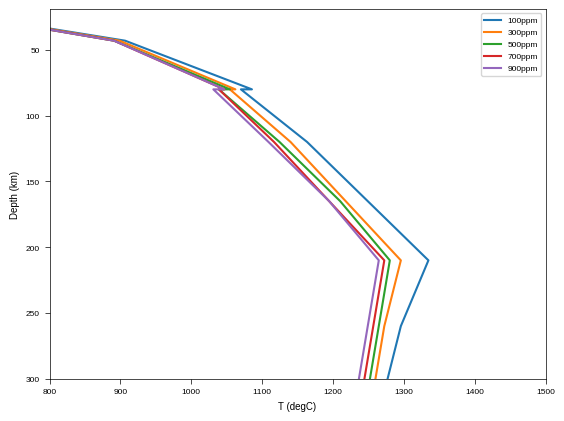

In [16]:
fig, axes = plt.subplots(1, 1, sharex=False, sharey=False)#, figsize=(20,15)) 
#
ax=axes
grain_size=10
oscillation_period=100
for COH in range(100,1000,200):
    #PUM
    TABLE_PUM_corr=lib.mantle_melt_atten_correction_Behn2009(table_PUM,grain_size,oscillation_period,COH)
    PUM= lib.vel_vs_to_temp_prop_out(tomo_in[:,0],tomo_in[:,3],TABLE_PUM_corr);
    use=PUM.copy()
    xplot=2 #T
    yplot=0 #d
    ax.plot(use[:,xplot],use[:,yplot],label=str(COH)+'ppm')

ax.set_ylim(300,19)
ax.legend()
ax.set_xlim(800,1500)
ax.set_xlabel('T (degC)');ax.set_ylabel('Depth (km)')


In [17]:
#Output: Output: [depth,P_out,Temperature_out,Density_out,Vp_out,Vs_out,diff_Vp,melt_out)
PUM= lib.vel_vp_to_temp_prop_out(tomo_in[:,0],tomo_in[:,2],TABLE_PUM_corr);
Pr1= lib.vel_vp_to_temp_prop_out(tomo_in[:,0],tomo_in[:,2],TABLE_Pr_1_corr);
Arc1= lib.vel_vp_to_temp_prop_out(tomo_in[:,0],tomo_in[:,2],TABLE_Arc_1_corr);


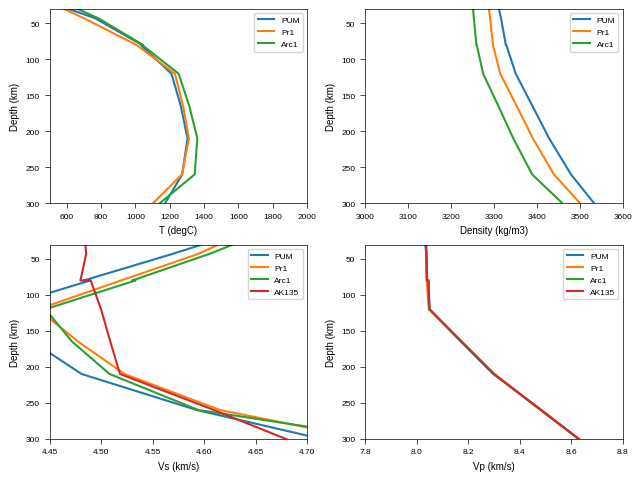

In [18]:
fig, axes = plt.subplots(2, 2, sharex=False, sharey=False)#, figsize=(20,15)) 
#
ax=axes[0,0]
#PUM
use=PUM.copy()
xplot=2 #T
yplot=0 #d
ax.plot(use[:,xplot],use[:,yplot],label='PUM')
#Pr1
use=Pr1.copy()
ax.plot(use[:,xplot],use[:,yplot],label='Pr1')
#Arc
use=Arc1.copy()
ax.plot(use[:,xplot],use[:,yplot],label='Arc1')
ax.legend()
ax.set_xlim(500,2000)
ax.set_xlabel('T (degC)');ax.set_ylabel('Depth (km)')


#density
ax=axes[0,1]
#PUM
use=PUM.copy()
xplot=3 #T
yplot=0 #d
ax.plot(use[:,xplot],use[:,yplot],label='PUM')
#Pr1
use=Pr1.copy()
ax.plot(use[:,xplot],use[:,yplot],label='Pr1')
#Arc
use=Arc1.copy()
ax.plot(use[:,xplot],use[:,yplot],label='Arc1')
ax.legend()
ax.set_xlim(3000,3600)
ax.set_xlabel('Density (kg/m3)');ax.set_ylabel('Depth (km)')


#Vs
ax=axes[1,0]
#PUM
use=PUM.copy()
xplot=5 #T
yplot=0 #d
ax.plot(use[:,xplot],use[:,yplot],label='PUM')
#Pr1
use=Pr1.copy()
ax.plot(use[:,xplot],use[:,yplot],label='Pr1')
#Arc
use=Arc1.copy()
ax.plot(use[:,xplot],use[:,yplot],label='Arc1')
ax.plot(tomo_in[:,3],tomo_in[:,0],label='AK135')
ax.legend()
ax.set_xlim(4.45,4.7)#ax.set_xlim(7.5,9)
ax.set_xlabel('Vs (km/s)');ax.set_ylabel('Depth (km)')



#Vp
ax=axes[1,1]
#PUM
use=PUM.copy()
xplot=4 #T
yplot=0 #d
ax.plot(use[:,xplot],use[:,yplot],label='PUM')
#Pr1
use=Pr1.copy()
ax.plot(use[:,xplot],use[:,yplot],label='Pr1')
#Arc
use=Arc1.copy()
ax.plot(use[:,xplot],use[:,yplot],label='Arc1')
ax.plot(tomo_in[:,2],tomo_in[:,0],label='AK135')
ax.legend()
ax.set_xlim(7.8,8.8)
ax.set_xlabel('Vp (km/s)');ax.set_ylabel('Depth (km)')

for i, ax in enumerate(axes.flat):
   ax.set_ylim(300,30)
    

plt.tight_layout()

In [22]:
#Output: Output: [depth,P_out,Temperature_out,Density_out,Vp_out,Vs_out,diff_Vp,melt_out)
PUM= lib.vel_vpvs_to_temp_prop_out(tomo_in[:,0],tomo_in[:,2]/tomo_in[:,3],TABLE_PUM_corr);
Pr1= lib.vel_vp_to_temp_prop_out(tomo_in[:,0],tomo_in[:,2]/tomo_in[:,3],TABLE_Pr_1_corr);
Arc1= lib.vel_vp_to_temp_prop_out(tomo_in[:,0],tomo_in[:,2]/tomo_in[:,3],TABLE_Arc_1_corr);


/tmp/ipykernel_1505259/37867462.py:2: RuntimeWarning: divide by zero encountered in divide
  PUM= lib.vel_vpvs_to_temp_prop_out(tomo_in[:,0],tomo_in[:,2]/tomo_in[:,3],TABLE_PUM_corr);
/home/ajay/projects/V2RhoT_gibbs/V2RhoT_gibbs_lib.py:1156: RuntimeWarning: invalid value encountered in scalar divide
  diff_VpVs.append(((VpVs_in-vp/vs)/VpVs_in)*100)
/tmp/ipykernel_1505259/37867462.py:3: RuntimeWarning: divide by zero encountered in divide
  Pr1= lib.vel_vp_to_temp_prop_out(tomo_in[:,0],tomo_in[:,2]/tomo_in[:,3],TABLE_Pr_1_corr);
/home/ajay/projects/V2RhoT_gibbs/V2RhoT_gibbs_lib.py:1112: RuntimeWarning: invalid value encountered in scalar divide
  diff_Vp.append(((Vp_in-vp)/Vp_in)*100)
/tmp/ipykernel_1505259/37867462.py:4: RuntimeWarning: divide by zero encountered in divide
  Arc1= lib.vel_vp_to_temp_prop_out(tomo_in[:,0],tomo_in[:,2]/tomo_in[:,3],TABLE_Arc_1_corr);


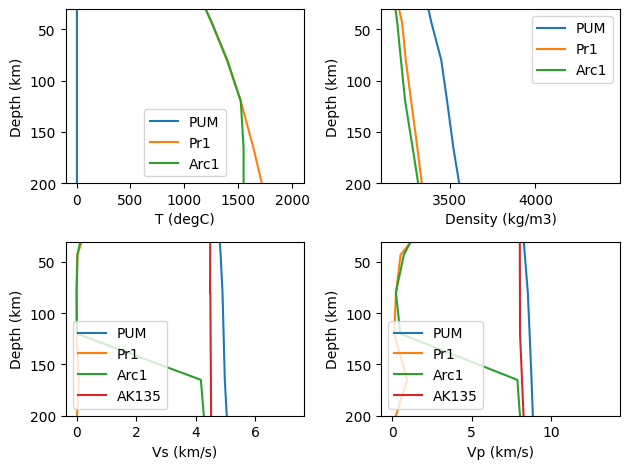

In [23]:
fig, axes = plt.subplots(2, 2, sharex=False, sharey=False)#, figsize=(20,15)) 
#
ax=axes[0,0]
#PUM
use=PUM.copy()
xplot=2 #T
yplot=0 #d
ax.plot(use[:,xplot],use[:,yplot],label='PUM')
#Pr1
use=Pr1.copy()
ax.plot(use[:,xplot],use[:,yplot],label='Pr1')
#Arc
use=Arc1.copy()
ax.plot(use[:,xplot],use[:,yplot],label='Arc1')
ax.legend()
#ax.set_xlim(500,2000)
ax.set_xlabel('T (degC)');ax.set_ylabel('Depth (km)')


#density
ax=axes[0,1]
#PUM
use=PUM.copy()
xplot=3 #T
yplot=0 #d
ax.plot(use[:,xplot],use[:,yplot],label='PUM')
#Pr1
use=Pr1.copy()
ax.plot(use[:,xplot],use[:,yplot],label='Pr1')
#Arc
use=Arc1.copy()
ax.plot(use[:,xplot],use[:,yplot],label='Arc1')
ax.legend()
#ax.set_xlim(3000,3600)
ax.set_xlabel('Density (kg/m3)');ax.set_ylabel('Depth (km)')


#Vs
ax=axes[1,0]
#PUM
use=PUM.copy()
xplot=5 #T
yplot=0 #d
ax.plot(use[:,xplot],use[:,yplot],label='PUM')
#Pr1
use=Pr1.copy()
ax.plot(use[:,xplot],use[:,yplot],label='Pr1')
#Arc
use=Arc1.copy()
ax.plot(use[:,xplot],use[:,yplot],label='Arc1')
ax.plot(tomo_in[:,3],tomo_in[:,0],label='AK135')
ax.legend()
#ax.set_xlim(4.45,4.7)#ax.set_xlim(7.5,9)
ax.set_xlabel('Vs (km/s)');ax.set_ylabel('Depth (km)')



#Vp
ax=axes[1,1]
#PUM
use=PUM.copy()
xplot=4 #T
yplot=0 #d
ax.plot(use[:,xplot],use[:,yplot],label='PUM')
#Pr1
use=Pr1.copy()
ax.plot(use[:,xplot],use[:,yplot],label='Pr1')
#Arc
use=Arc1.copy()
ax.plot(use[:,xplot],use[:,yplot],label='Arc1')
ax.plot(tomo_in[:,2],tomo_in[:,0],label='AK135')
ax.legend()
#ax.set_xlim(7.8,8.8)
ax.set_xlabel('Vp (km/s)');ax.set_ylabel('Depth (km)')

for i, ax in enumerate(axes.flat):
   ax.set_ylim(200,30)
    

plt.tight_layout()